In [1]:
import datetime
import json
import os
import re
import warnings
from collections import defaultdict

import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.image as image
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import networkx as nx
import numpy as np
import pandas as pd
import pycountry

import seaborn as sns
import shapely
from shapely import LineString, MultiPoint, Point
from cartopy import crs as ccrs
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

from IPython.core import display
from matplotlib._layoutgrid import plot_children
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.transforms import ScaledTranslation

import scipy
import scipy.stats as stats
from scipy.stats import theilslopes
import pymannkendall as mk

from adjustText import adjust_text

import polars as pl

In [2]:
mpl.font_manager.fontManager.addfont(
    "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf",
)

mpl.rcdefaults()

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

In [3]:
iso2_to_iso3 = {c.alpha_2: c.alpha_3 for c in pycountry.countries}
iso3_to_iso2 = {c.alpha_3: c.alpha_2 for c in pycountry.countries}

cn_south = gpd.read_file("../processed_data/shp/cn_south.geojson")

adm0 = gpd.read_file("../processed_big_data/gadm_level0.gpkg")
adm0_geometry_s = adm0.geometry.simplify(tolerance=0.1)

adm0_s = gpd.GeoDataFrame(adm0, geometry=adm0_geometry_s)
adm0 = adm0_s[~adm0_s["GID_0"].isin(["ATA"])].copy()
adm0["alpha2"] = adm0["GID_0"].map(lambda x: iso3_to_iso2.get(x))

In [4]:
popd_worldpop = pd.read_csv("../data/PWD_2020_national_1km.csv").copy()
popd_worldpop["iso2"] = popd_worldpop["ISO"].map(lambda x: iso3_to_iso2.get(x))
country_code_to_lonlat = {
    a: (b, c)
    for _, (a, b, c) in popd_worldpop[["iso2", "PWC_Lon", "PWC_Lat"]].iterrows()
}

airports = pd.read_csv("../processed_data/airports.csv", sep="\t", keep_default_na=False)
airport_to_alpha2 = airports.set_index("IATA")["ISO2"].to_dict()
airport_to_alpha3 = airports.set_index("IATA")["ISO3"].to_dict()

airport_to_alpha2["INO"] = "CD"
airport_to_alpha3["INO"] = "COD"

airport_code_to_lonlat = {
    a: (c, b) for a, b, c in airports[["IATA", "lat", "lon"]].values
}

airport_geometry = [Point(xy) for xy in zip(airports["lon"], airports["lat"])]
airport_geodata = gpd.GeoDataFrame(airports, crs="EPSG:4326", geometry=airport_geometry)

In [5]:
country_info = pd.read_excel("../data/country_info.xlsx", keep_default_na=False)
country_info

,ISO2,ISO3,name,SOV_A3,UN_member,WHO_member,OAG_pax,Total_traffic,International_traffic,National_traffic
0,AF,AFG,Afghanistan,AFG,T,T,T,T,T,T
1,AO,AGO,Angola,AGO,T,T,T,T,T,T
2,AL,ALB,Albania,ALB,T,T,T,T,T,F
3,AD,AND,Andorra,AND,T,T,F,F,F,F
4,AE,ARE,United Arab Emirates,ARE,T,T,T,T,T,T
...,...,...,...,...,...,...,...,...,...,...
244,WS,WSM,Samoa,WSM,T,T,T,T,T,F
245,YE,YEM,Yemen,YEM,T,T,T,T,T,T
246,ZA,ZAF,South Africa,ZAF,T,T,T,T,T,T
247,ZM,ZMB,Zambia,ZMB,T,T,T,T,T,T


In [6]:
countries_tot = country_info.query('Total_traffic == "T"')["ISO2"].values
countries_int = country_info.query('International_traffic == "T"')["ISO2"].values
countries_dom = country_info.query('National_traffic == "T"')["ISO2"].values

# load traffic data

In [7]:
all_traffic_yearly = pl.read_csv("../processed_big_data/all_traffic_yearly_update.csv")
all_traffic_yearly_ = all_traffic_yearly.filter(pl.col("dep_country").is_in(countries_tot) | pl.col("arr_country").is_in(countries_tot))

In [37]:
global_traffic = all_traffic_yearly_.group_by(['year', 'type']).agg(pl.col("traffic").sum())
global_traffic = pd.pivot_table(global_traffic.to_pandas(), index='year', columns='type', values='traffic') 
global_traffic['total'] = global_traffic['international'] + global_traffic['national']

global_traffic


type,international,national,total
year,,,
2011,9.760800e+08,1.355635e+09,2.331715e+09
2012,1.024988e+09,1.411171e+09,2.436159e+09
2013,1.120318e+09,1.503261e+09,2.623580e+09
2014,1.185930e+09,1.601648e+09,2.787578e+09
2015,1.267572e+09,1.707471e+09,2.975043e+09
2016,1.370629e+09,1.811610e+09,3.182239e+09
2017,1.474158e+09,1.970952e+09,3.445110e+09
2018,1.565552e+09,2.109989e+09,3.675541e+09
2019,1.612871e+09,2.170904e+09,3.783775e+09


In [22]:
national_int_traffic = pd.read_csv("../processed_big_data/national_int_traffic.csv", index_col=0)
national_dom_traffic = pd.read_csv("../processed_big_data/national_dom_traffic.csv", index_col=0)

national_traffic = national_dom_traffic + national_int_traffic

# trend

## global trend

In [38]:
yy = global_traffic.loc[2011:2019, 'total'].values
global_total_trend = theilslopes(yy).slope / yy.mean()

yy = global_traffic.loc[2011:2019, 'international'].values
global_int_trend = theilslopes(yy).slope / yy.mean()

yy = global_traffic.loc[2011:2019, 'national'].values
global_dom_trend = theilslopes(yy).slope / yy.mean()


global_total_trend, global_int_trend, global_dom_trend

(np.float64(0.06351563968217648),
 np.float64(0.06525824684835349),
 np.float64(0.06064289015658758))

## national trend

In [33]:
res = []
for country in national_traffic.columns:
    y = national_traffic.loc[2011:2019, country].values
    mk_res = mk.original_test(y, alpha=0.05)
    slope_res = theilslopes(y)

    res.append(
        [
            country,
            y[0],
            y[-1],
            y.mean(),
            mk_res.trend,
            mk_res.p,
            mk_res.s,
            mk_res.Tau,
            slope_res.slope,
            slope_res.low_slope,
            slope_res.high_slope,
        ]
    )

national_traffic_trend = pd.DataFrame(
    res,
    columns=[
        "country",
        "traffic_2011",
        "traffic_2019",
        "traffic_avg",
        "trend",
        "p",
        "s",
        "tau",
        "slope",
        "slope_low",
        "slope_high",
    ],
)
national_traffic_trend["pct_slope"] = (
    national_traffic_trend["slope"] / national_traffic_trend["traffic_avg"]
)
national_traffic_trend["pct_slope_low"] = (
    national_traffic_trend["slope_low"] / national_traffic_trend["traffic_avg"]
)
national_traffic_trend["pct_slope_high"] = (
    national_traffic_trend["slope_high"] / national_traffic_trend["traffic_avg"]
)
national_traffic_trend = national_traffic_trend.sort_values(
    "pct_slope", ascending=False
)

In [34]:
res = []
for country in national_dom_traffic.columns:
    y = national_dom_traffic.loc[2011:2019, country].values
    mk_res = mk.original_test(y, alpha=0.05)
    slope_res = theilslopes(y)

    res.append(
        [
            country,
            y[0],
            y[-1],
            y.mean(),
            mk_res.trend,
            mk_res.p,
            mk_res.s,
            mk_res.Tau,
            slope_res.slope,
            slope_res.low_slope,
            slope_res.high_slope,
        ]
    )

national_dom_traffic_trend = pd.DataFrame(
    res,
    columns=[
        "country",
        "traffic_2011",
        "traffic_2019",
        "traffic_avg",
        "trend",
        "p",
        "s",
        "tau",
        "slope",
        "slope_low",
        "slope_high",
    ],
)
national_dom_traffic_trend["pct_slope"] = (
    national_dom_traffic_trend["slope"] / national_dom_traffic_trend["traffic_avg"]
)
national_dom_traffic_trend["pct_slope_low"] = (
    national_dom_traffic_trend["slope_low"] / national_dom_traffic_trend["traffic_avg"]
)
national_dom_traffic_trend["pct_slope_high"] = (
    national_dom_traffic_trend["slope_high"] / national_dom_traffic_trend["traffic_avg"]
)
national_dom_traffic_trend = national_dom_traffic_trend.sort_values(
    "pct_slope", ascending=False
)

In [35]:
res = []
for country in national_int_traffic.columns:
    y = national_int_traffic.loc[2011:2019, country].values
    mk_res = mk.original_test(y, alpha=0.05)
    slope_res = theilslopes(y)

    res.append(
        [
            country,
            y[0],
            y[-1],
            y.mean(),
            mk_res.trend,
            mk_res.p,
            mk_res.s,
            mk_res.Tau,
            slope_res.slope,
            slope_res.low_slope,
            slope_res.high_slope,
        ]
    )

national_int_traffic_trend = pd.DataFrame(
    res,
    columns=[
        "country",
        "traffic_2011",
        "traffic_2019",
        "traffic_avg",
        "trend",
        "p",
        "s",
        "tau",
        "slope",
        "slope_low",
        "slope_high",
    ],
)
national_int_traffic_trend["pct_slope"] = (
    national_int_traffic_trend["slope"] / national_int_traffic_trend["traffic_avg"]
)
national_int_traffic_trend["pct_slope_low"] = (
    national_int_traffic_trend["slope_low"] / national_int_traffic_trend["traffic_avg"]
)
national_int_traffic_trend["pct_slope_high"] = (
    national_int_traffic_trend["slope_high"] / national_int_traffic_trend["traffic_avg"]
)
national_int_traffic_trend = national_int_traffic_trend.sort_values(
    "pct_slope", ascending=False
)

In [ ]:
# national_traffic_trend.to_csv("./results/trend_national.csv", index=False)
# national_dom_traffic_trend.to_csv("./results/trend_national_dom.csv", index=False)
# national_int_traffic_trend.to_csv("./results/trend_national_int.csv", index=False)

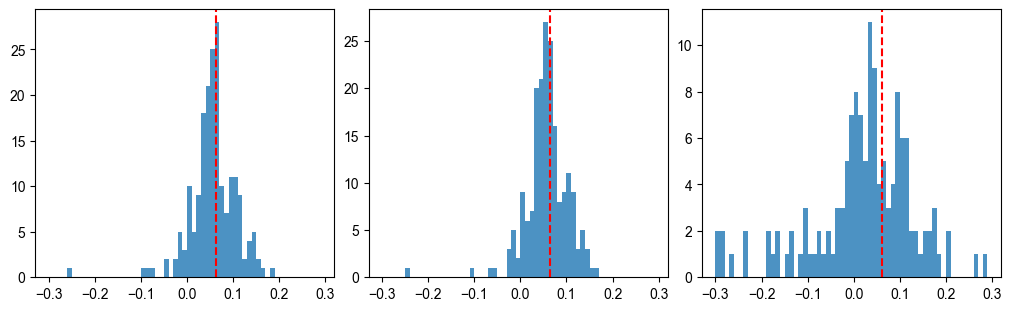

In [39]:
plt.figure(figsize=(10, 3), layout="constrained")

plt.subplot(131)
plt.hist(
    national_traffic_trend.query("country in @countries_int")["pct_slope"].values,
    bins=np.arange(-0.3, 0.3, 0.01),
    alpha=0.8,
)
plt.axvline(x=global_total_trend, color="r", ls="--")

plt.subplot(132)
plt.hist(
    national_int_traffic_trend.query("country in @countries_int")["pct_slope"].values,
    bins=np.arange(-0.3, 0.3, 0.01),
    alpha=0.8,
)
plt.axvline(x=global_int_trend, color="r", ls="--")


plt.subplot(133)
plt.hist(
    national_dom_traffic_trend.query("country in @countries_dom")["pct_slope"].values,
    bins=np.arange(-0.3, 0.3, 0.01),
    alpha=0.8,
)
plt.axvline(x=global_dom_trend, color="r", ls="--")


plt.show()

In [41]:
# regions = [
#     "Africa",
#     "Asia-Pacific",
#     "Europe",
#     "Latin America and the Caribbean",
#     "Middle East",
#     "Northern America",
# ]

# res = []
# prefixs = ["total", "nat", "int"]
# dfs = [national_traffic_trend, national_dom_traffic_trend, national_int_traffic_trend]

# for i, (prefix, df) in enumerate(zip(prefixs, dfs)):
#     res_ = []
#     for region in regions:
#         codes = [
#             country for country in df.country if country2region3[country] == region
#         ]
#         sub = df.query("country in @codes")

#         abs_change = sub.apply(
#             lambda x: f"{x['slope'] / 1e3:.2f} ({x['slope_low'] / 1e3:.2f}, {x['slope_high'] / 1e3:.2f})",
#             axis=1,
#         )
#         rel_change = sub.apply(
#             lambda x: f"{x['pct_slope'] * 100:.2f} ({x['pct_slope_low'] * 100:.2f}, {x['pct_slope_high'] * 100:.2f})",
#             axis=1,
#         )

#         res_.append(
#             pd.DataFrame(
#                 {
#                     "codes": codes,
#                     f"{prefix}_abs_change": abs_change,
#                     f"{prefix}_rel_change": rel_change,
#                 }
#             )
#         )

#     res.append(pd.concat(res_).set_index("codes"))

# res = pd.concat(res, axis=1)
# res["country"] = res.index.map(
#     lambda x: pycountry.countries.get(alpha_2=x).name
#     if pycountry.countries.get(alpha_2=x)
#     else ""
# )
# res["region"] = res.index.map(country2region3)

# vals = [
#     "region",
#     "country",
#     "total_abs_change",
#     "total_rel_change",
#     "nat_abs_change",
#     "nat_rel_change",
#     "int_abs_change",
#     "int_rel_change",
# ]
# res[vals]

In [44]:
def trans_trend_color(x):
    if x == "increasing":
        return "#AE75A2"
    elif x == "decreasing":
        return "#1964B0"
    else:
        return "gray"

In [46]:
cm = 1 / 2.54  # centimeters in inches

style = {
    "lines.linewidth": 0.7,
    "lines.markeredgewidth": 0.3,
    "font.size": 7.0,
    "font.family": "Arial",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.5,
    "axes.grid": False,
    "axes.labelsize": 7,
    "axes.labelpad": 3,
    "axes.labelweight": "normal",
    "axes.labelcolor": "black",
    "axes.xmargin": 0.01,
}


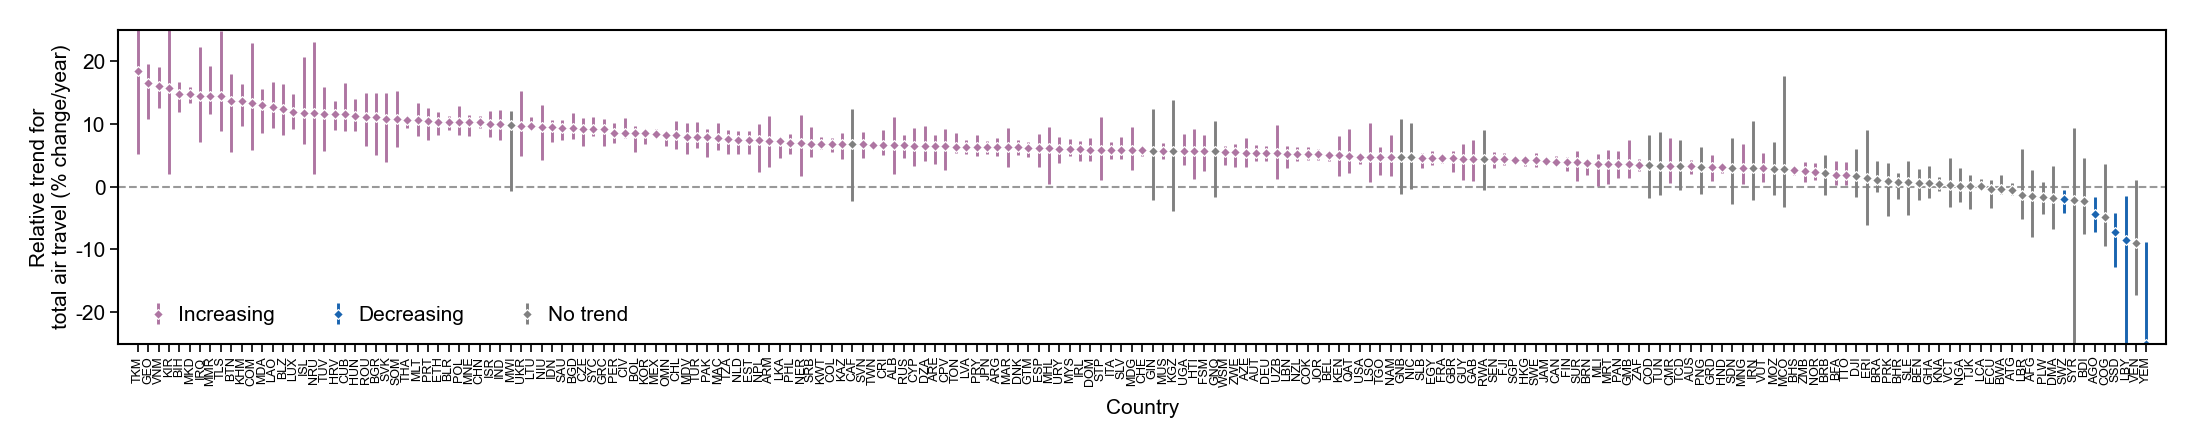

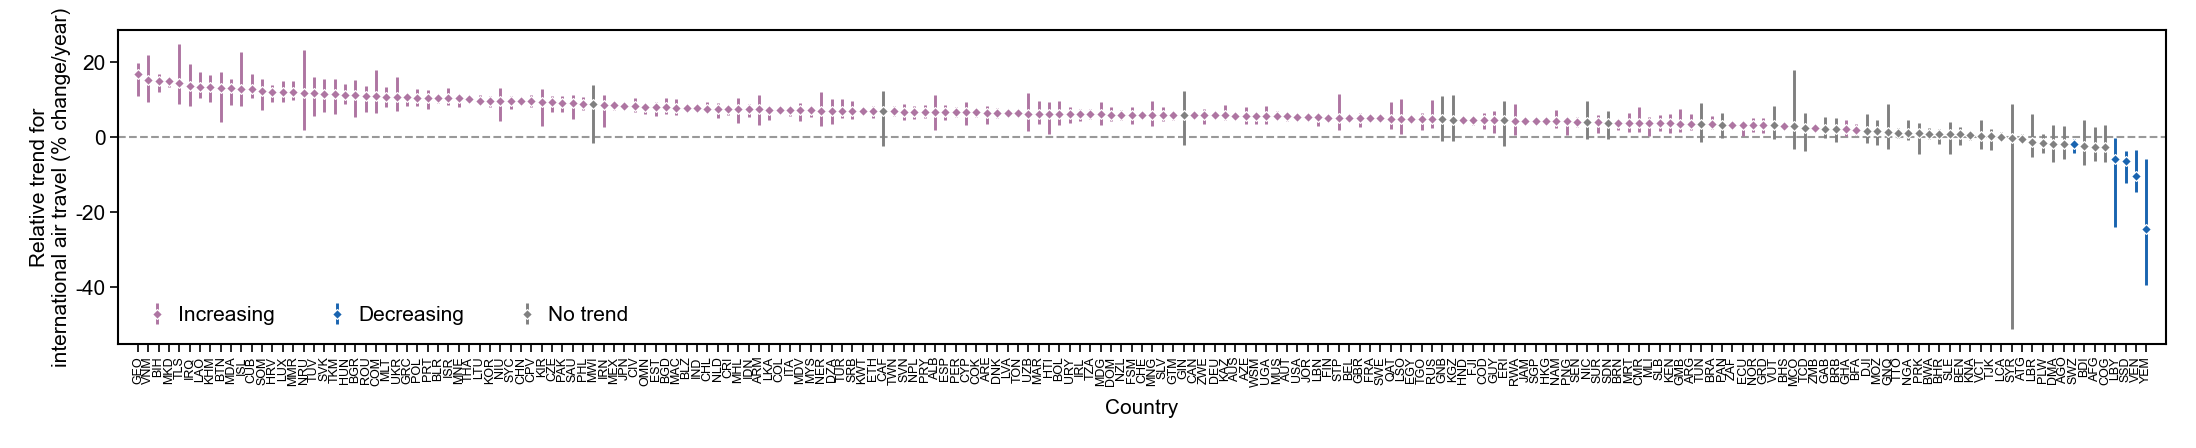

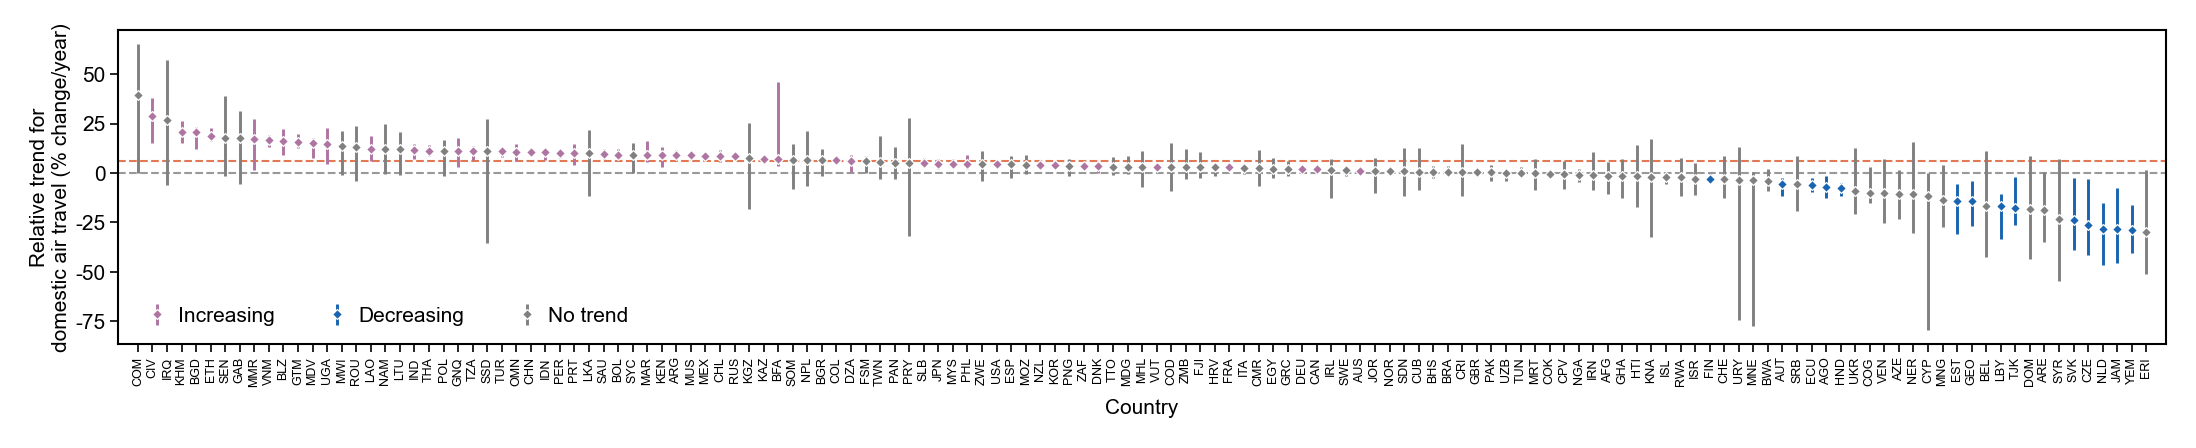

In [50]:
tmp = national_traffic_trend.query("country in @countries_tot").sort_values(
    "pct_slope", ascending=False
)
lb = tmp["pct_slope_low"].values
ub = tmp["pct_slope_high"].values
md = tmp["pct_slope"].values
nobs = len(tmp)
sigi = (tmp["trend"] == "increasing").values
sigd = (tmp["trend"] == "decreasing").values
sign = (tmp["trend"] == "no trend").values
tmp1 = national_int_traffic_trend.query("country in @countries_int").sort_values(
    "pct_slope", ascending=False
)
lb1 = tmp1["pct_slope_low"].values
ub1 = tmp1["pct_slope_high"].values
md1 = tmp1["pct_slope"].values
nobs1 = len(tmp1)
sigi1 = (tmp1["trend"] == "increasing").values
sigd1 = (tmp1["trend"] == "decreasing").values
sign1 = (tmp1["trend"] == "no trend").values

tmp2 = national_dom_traffic_trend.query("country in @countries_dom").sort_values(
    "pct_slope", ascending=False
)
lb2 = tmp2["pct_slope_low"].values
ub2 = tmp2["pct_slope_high"].values
md2 = tmp2["pct_slope"].values
nobs2 = len(tmp2)
sigi2 = (tmp2["trend"] == "increasing").values
sigd2 = (tmp2["trend"] == "decreasing").values
sign2 = (tmp2["trend"] == "no trend").values

cm = 1 / 2.54  # centimeters in inches

style = {
    "lines.linewidth": 0.7,
    "lines.markeredgewidth": 0.3,
    "font.size": 7.0,
    "font.family": "Arial",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.5,
    "axes.grid": False,
    "axes.labelsize": 7,
    "axes.labelpad": 3,
    "axes.labelweight": "normal",
    "axes.labelcolor": "black",
    "axes.xmargin": 0.01,
}

with mpl.rc_context(style):
    cm = 1 / 2.54  # centimeters in inches

    fig, ax1 = plt.subplots(
        1, 1, figsize=(18.3 * cm, 3.5 * cm), dpi=300, layout="constrained"
    )
    ax1.errorbar(
        x=np.arange(nobs)[sigi],
        y=md[sigi],
        yerr=np.vstack([md - lb, ub - md])[:, sigi],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="#AE75A2",
        ecolor="#AE75A2",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="Increasing",
    )
    ax1.errorbar(
        x=np.arange(nobs)[sigd],
        y=md[sigd],
        yerr=np.vstack([md - lb, ub - md])[:, sigd],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="#1964B0",
        ecolor="#1964B0",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="Decreasing",
    )
    ax1.errorbar(
        x=np.arange(nobs)[sign],
        y=md[sign],
        yerr=np.vstack([md - lb, ub - md])[:, sign],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="gray",
        ecolor="gray",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="No trend",
    )


    ax1.axhline(y=0, ls="--", color="gray", alpha=0.8, zorder=-99, lw=0.5)
    ax1.legend(
        fontsize=5,
        frameon=False,
        loc="lower left",
        handletextpad=0,
        labelspacing=0,
        ncols=3,
    )

    # ax1.grid(axis="x", lw=.3, color='#DEDEDE', alpha=.6, zorder=-99)
    ax1.set_ylim(-0.25, 0.25)
    ax1.set_xmargin(0.01)
    ax1.set_xticks(np.arange(nobs), [iso2_to_iso3[x] for x in tmp["country"].values])
    ax1.yaxis.set_major_formatter(lambda x, pos: f"{x * 100:.0f}")
    ax1.tick_params(axis="y", labelsize=5, size=2, width=0.4, pad=1)
    ax1.tick_params(axis="x", labelsize=3, size=2, width=0.4, pad=1, labelrotation=90)

    ax1.set_ylabel(
        "Relative trend for\ntotal air travel (% change/year)", fontsize=5, labelpad=1
    )
    ax1.set_xlabel("Country", fontsize=5)

    fig, ax2 = plt.subplots(
        1, 1, figsize=(18.3 * cm, 3.5 * cm), dpi=300, layout="constrained"
    )
    ax2.errorbar(
        x=np.arange(nobs1)[sigi1],
        y=md1[sigi1],
        yerr=np.vstack([md1 - lb1, ub1 - md1])[:, sigi1],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="#AE75A2",
        ecolor="#AE75A2",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="Increasing",
    )
    ax2.errorbar(
        x=np.arange(nobs1)[sigd1],
        y=md1[sigd1],
        yerr=np.vstack([md1 - lb1, ub1 - md1])[:, sigd1],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="#1964B0",
        ecolor="#1964B0",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="Decreasing",
    )
    ax2.errorbar(
        x=np.arange(nobs1)[sign1],
        y=md1[sign1],
        yerr=np.vstack([md1 - lb1, ub1 - md1])[:, sign1],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="gray",
        ecolor="gray",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="No trend",
    )
    ax2.axhline(y=0, ls="--", color="gray", alpha=0.8, zorder=-99, lw=0.5)
    ax2.legend(
        fontsize=5,
        frameon=False,
        loc="lower left",
        handletextpad=0,
        labelspacing=0,
        ncols=3,
    )

    # ax2.set_ylim(-0.25, 0.25)
    ax2.set_xmargin(0.01)
    ax2.set_xticks(np.arange(nobs1), [iso2_to_iso3[x] for x in tmp1["country"].values])
    ax2.yaxis.set_major_formatter(lambda x, pos: f"{x * 100:.0f}")
    ax2.tick_params(axis="y", labelsize=5, size=2, width=0.4, pad=1)
    ax2.tick_params(axis="x", labelsize=3, size=2, width=0.4, pad=1, labelrotation=90)

    ax2.set_ylabel(
        "Relative trend for\ninternational air travel (% change/year)",
        fontsize=5,
        labelpad=1,
    )
    ax2.set_xlabel("Country", fontsize=5)

    fig, ax3 = plt.subplots(
        1, 1, figsize=(18.3 * cm, 3.5 * cm), dpi=300, layout="constrained"
    )
    ax3.errorbar(
        x=np.arange(nobs2)[sigi2],
        y=md2[sigi2],
        yerr=np.vstack([md2 - lb2, ub2 - md2])[:, sigi2],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="#AE75A2",
        ecolor="#AE75A2",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="Increasing",
    )
    ax3.errorbar(
        x=np.arange(nobs2)[sigd2],
        y=md2[sigd2],
        yerr=np.vstack([md2 - lb2, ub2 - md2])[:, sigd2],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="#1964B0",
        ecolor="#1964B0",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="Decreasing",
    )
    ax3.errorbar(
        x=np.arange(nobs2)[sign2],
        y=md2[sign2],
        yerr=np.vstack([md2 - lb2, ub2 - md2])[:, sign2],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="gray",
        ecolor="gray",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="No trend",
    )
    ax3.axhline(y=0, ls="--", color="gray", alpha=0.8, zorder=-99, lw=0.5)

    ax3.axhline(
        y=global_dom_trend, ls="--", color="#DB5829", alpha=0.8, zorder=-99, lw=0.5
    )

    ax3.legend(
        fontsize=5,
        frameon=False,
        loc="lower left",
        handletextpad=0,
        labelspacing=0,
        ncols=3,
    )

    # ax3.set_ylim(-0.75, 0.75)
    ax3.set_xmargin(0.01)
    ax3.set_xticks(np.arange(nobs2), [iso2_to_iso3[x] for x in tmp2["country"].values])
    ax3.yaxis.set_major_formatter(lambda x, pos: f"{x * 100:.0f}")
    ax3.tick_params(axis="y", labelsize=5, size=2, width=0.4, pad=1)
    ax3.tick_params(axis="x", labelsize=3, size=2, width=0.4, pad=1, labelrotation=90)

    ax3.set_ylabel(
        "Relative trend for\ndomestic air travel (% change/year)",
        fontsize=5,
        labelpad=1,
    )
    ax3.set_xlabel("Country", fontsize=5)

    # plot_children(fig)
    plt.show()

## absolte trend

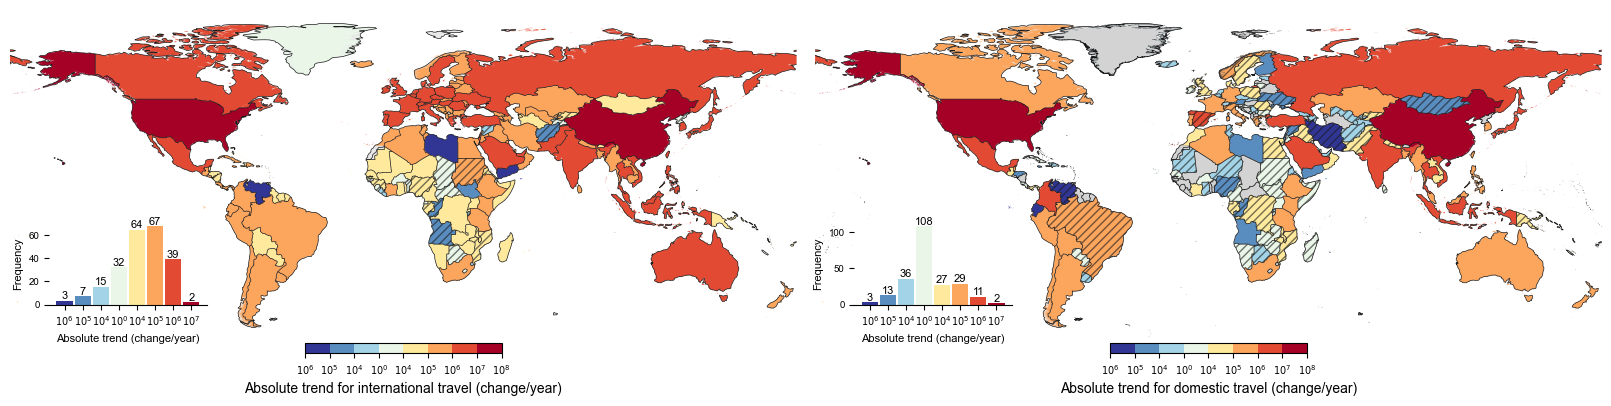

In [51]:
bins2 = [-1e6, -1e5, -1e4, 0, 1e4, 1e5, 1e6, 1e7, 1e8]
cmap2 = mpl.colormaps["RdYlBu_r"].resampled(len(bins2) - 1)


fig, axs = plt.subplots(
    1,
    2,
    figsize=(16, 10),
    subplot_kw={"projection": ccrs.PlateCarree()},
    layout="constrained",
)

for label, df, ax in zip(
    ["international", "domestic"],
    [national_int_traffic_trend, national_dom_traffic_trend],
    axs,
):
    var_dict2 = df.set_index("country")["slope"].to_dict()
    adm0_ = adm0.assign(var2=lambda x: x["alpha2"].map(var_dict2))
    adm0_["varc_2"] = pd.cut(adm0_["var2"], bins=bins2, ordered=True, right=False)

    ax_ = ax.inset_axes([0.05, 0.1, 0.2, 0.25])

    ax.set_extent([-180, 180, -60, 90])
    ax.set_axis_off()

    for i, (c, df_) in enumerate(adm0_.groupby(["varc_2"], observed=False)):
        ax.add_geometries(
            df_["geometry"].values,
            crs=ccrs.PlateCarree(),
            fc=cmap2(i / (len(bins2) - 1)),
        )
        ax_.bar(i, df_.shape[0], width=0.9, color=cmap2(i / (len(bins2) - 1)))
        ax_.text(
            i,
            df_.shape[0],
            f"{df_.shape[0]}",
            fontdict=dict(fontsize=8, va="bottom", ha="center"),
        )

    codes = df.loc[df["trend"] == "no trend", "country"].values
    ax.add_geometries(
        adm0_.loc[adm0_["alpha2"].isin(codes), "geometry"].values,
        crs=ccrs.PlateCarree(),
        fc="none",
        ec=".1",
        hatch="////",
        lw=0.1,
        alpha=0.6,
    )
    if label == "domestic":
        ax.add_geometries(
            adm0_.loc[~adm0_["alpha2"].isin(countries_dom), "geometry"].values,
            crs=ccrs.PlateCarree(),
            fc="lightgray",
            ec=".1",
            lw=0.1,
            alpha=1,
        )

    ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.5)
    ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.5)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)

    ax_.tick_params(axis="both", labelsize=7)
    ax_.set_xticks(
        np.arange(len(bins2) - 1),
        labels=[
            f"$10^{{{np.round(np.log10(np.abs(x + 1)), 0).astype(int)}}}$"
            for x in bins2[:-1]
        ],
    )
    ax_.set_xlabel(r"Absolute trend (change/year)", fontsize=8)
    ax_.set_ylabel("Frequency", fontsize=8)
    ax_.spines[["top", "left", "right"]].set_visible(False)

    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(cmap=cmap2),
        ax=ax,
        orientation="horizontal",
        shrink=0.25,
        pad=0,
    )
    cbar.set_ticks(
        np.linspace(0, 1, len(bins2)),
        labels=[
            f"$10^{{{np.round(np.log10(np.abs(x + 1)), 0).astype(int)}}}$"
            for x in bins2
        ],
        fontsize=7,
    )
    cbar.set_label(f"Absolute trend for {label} travel" + r" (change/year)")

plt.show()

## relative trend

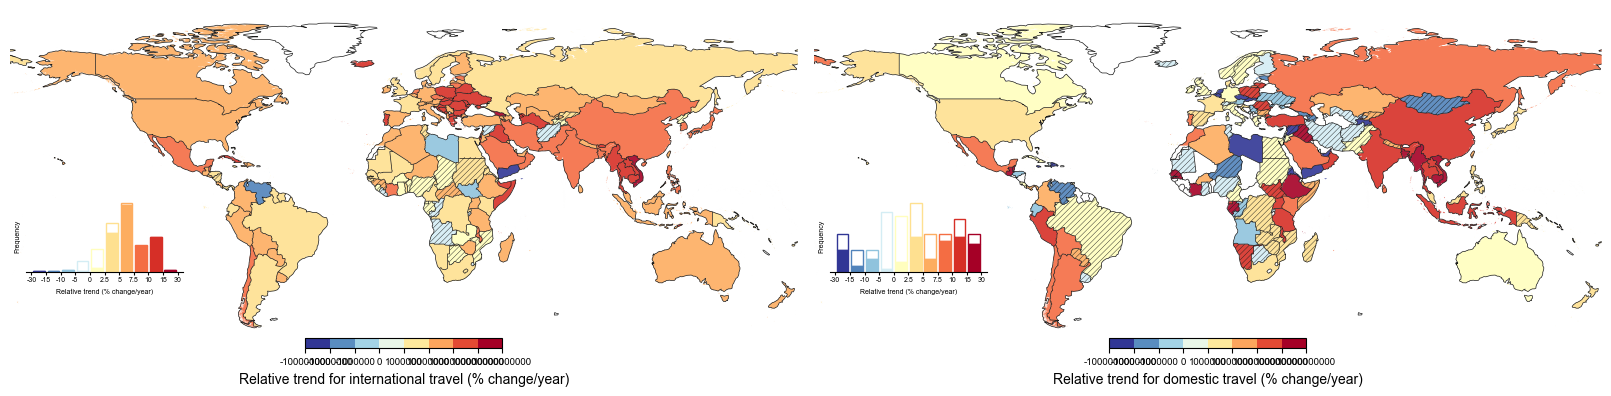

In [53]:
fig, axs = plt.subplots(
    1,
    2,
    figsize=(16, 10),
    subplot_kw={"projection": ccrs.PlateCarree()},
    layout="constrained",
)

for label, df, cc, ax in zip(
    ["international", "domestic"],
    [national_int_traffic_trend, national_dom_traffic_trend],
    [countries_int, countries_dom],
    axs,
):
    bins = np.array([-0.3, -0.15, -0.1, -0.05, 0, 0.025, 0.05, 0.075, 0.1, 0.15, 0.3])
    c1 = plt.cm.RdYlBu_r(np.linspace(0, 0.5, (bins < 0).sum(), endpoint=False))
    c2 = plt.cm.RdYlBu_r(np.linspace(0.5, 1, (bins > 0).sum()))
    cmap = ListedColormap(np.vstack([c1, c2]))
    norm = mcolors.BoundaryNorm(
        boundaries=bins, ncolors=len(bins) - 1, extend="neither"
    )

    ax.set_extent([-180, 180, -60, 90])
    ax.set_axis_off()

    var_dict = df.query("country in @cc").set_index("country")["pct_slope"].to_dict()
    adm0_ = adm0.assign(var1=lambda x: x["alpha2"].map(var_dict))
    ax.add_geometries(
        adm0_["geometry"].values,
        crs=ccrs.PlateCarree(),
        array=adm0_["var1"].values,
        cmap=cmap,
        norm=norm,
        alpha=0.9,
        rasterized=True,
    )

    codes = df.query("trend == 'no trend' and country in @cc")["country"].values
    ax.add_geometries(
        adm0_.loc[adm0_["alpha2"].isin(codes), "geometry"].values,
        crs=ccrs.PlateCarree(),
        fc="none",
        ec=".1",
        lw=0.0,
        hatch="//////",
        hatch_linewidth=0.3,
        alpha=1,
        rasterized=True,
    )

    ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.5)
    ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.5)
    ax.add_feature(cfeature.LAND, facecolor="#FFFFFF", alpha=0.5)

    ax_ = ax.inset_axes([0.02, 0.2, 0.2, 0.22])
    ct1 = pd.cut(
        df.query("country in @cc and trend != 'no trend'")["pct_slope"],
        bins=bins,
        ordered=True,
        right=False,
    ).value_counts(sort=False)
    ct2 = pd.cut(
        df.query("country in @cc and trend == 'no trend'")["pct_slope"],
        bins=bins,
        ordered=True,
        right=False,
    ).value_counts(sort=False)

    bars1 = ax_.bar(np.arange(len(ct1)), ct1.values)
    bars2 = ax_.bar(np.arange(len(ct2)), ct2.values, bottom=ct1.values)

    for i, (bar_1, bar_2) in enumerate(zip(bars1, bars2)):
        bar_1.set_fc(cmap(i / len(ct1)))
        bar_1.set_ec(cmap(i / len(ct1)))
        bar_2.set_fc("none")
        bar_2.set_ec(cmap(i / len(ct2)))

    ax_.tick_params(axis="both", size=2.5, pad=0.5)
    ax_.set_xticks(
        np.arange(len(bins)) - 0.5,
        labels=[
            f"{x * 100:.0f}" if x * 100 % 1 == 0 else f"{x * 100:.1f}" for x in bins
        ],
        fontsize=5,
        rotation=0,
    )
    ax_.set_yticks([])
    ax_.set_xlabel(r"Relative trend (% change/year)", fontsize=5)
    ax_.set_ylabel("Frequency", fontsize=5)
    ax_.spines[["top", "left", "right"]].set_visible(False)

    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(cmap=cmap2),
        ax=ax,
        orientation="horizontal",
        shrink=0.25,
        pad=0,
    )
    cbar.set_ticks(
        np.linspace(0, 1, len(bins2)),
        labels=[f"{x * 100:.0f}" for x in bins2],
        fontsize=7,
    )
    cbar.set_label(f"Relative trend for {label} travel" + r" (% change/year)")

plt.show()

# figure 3

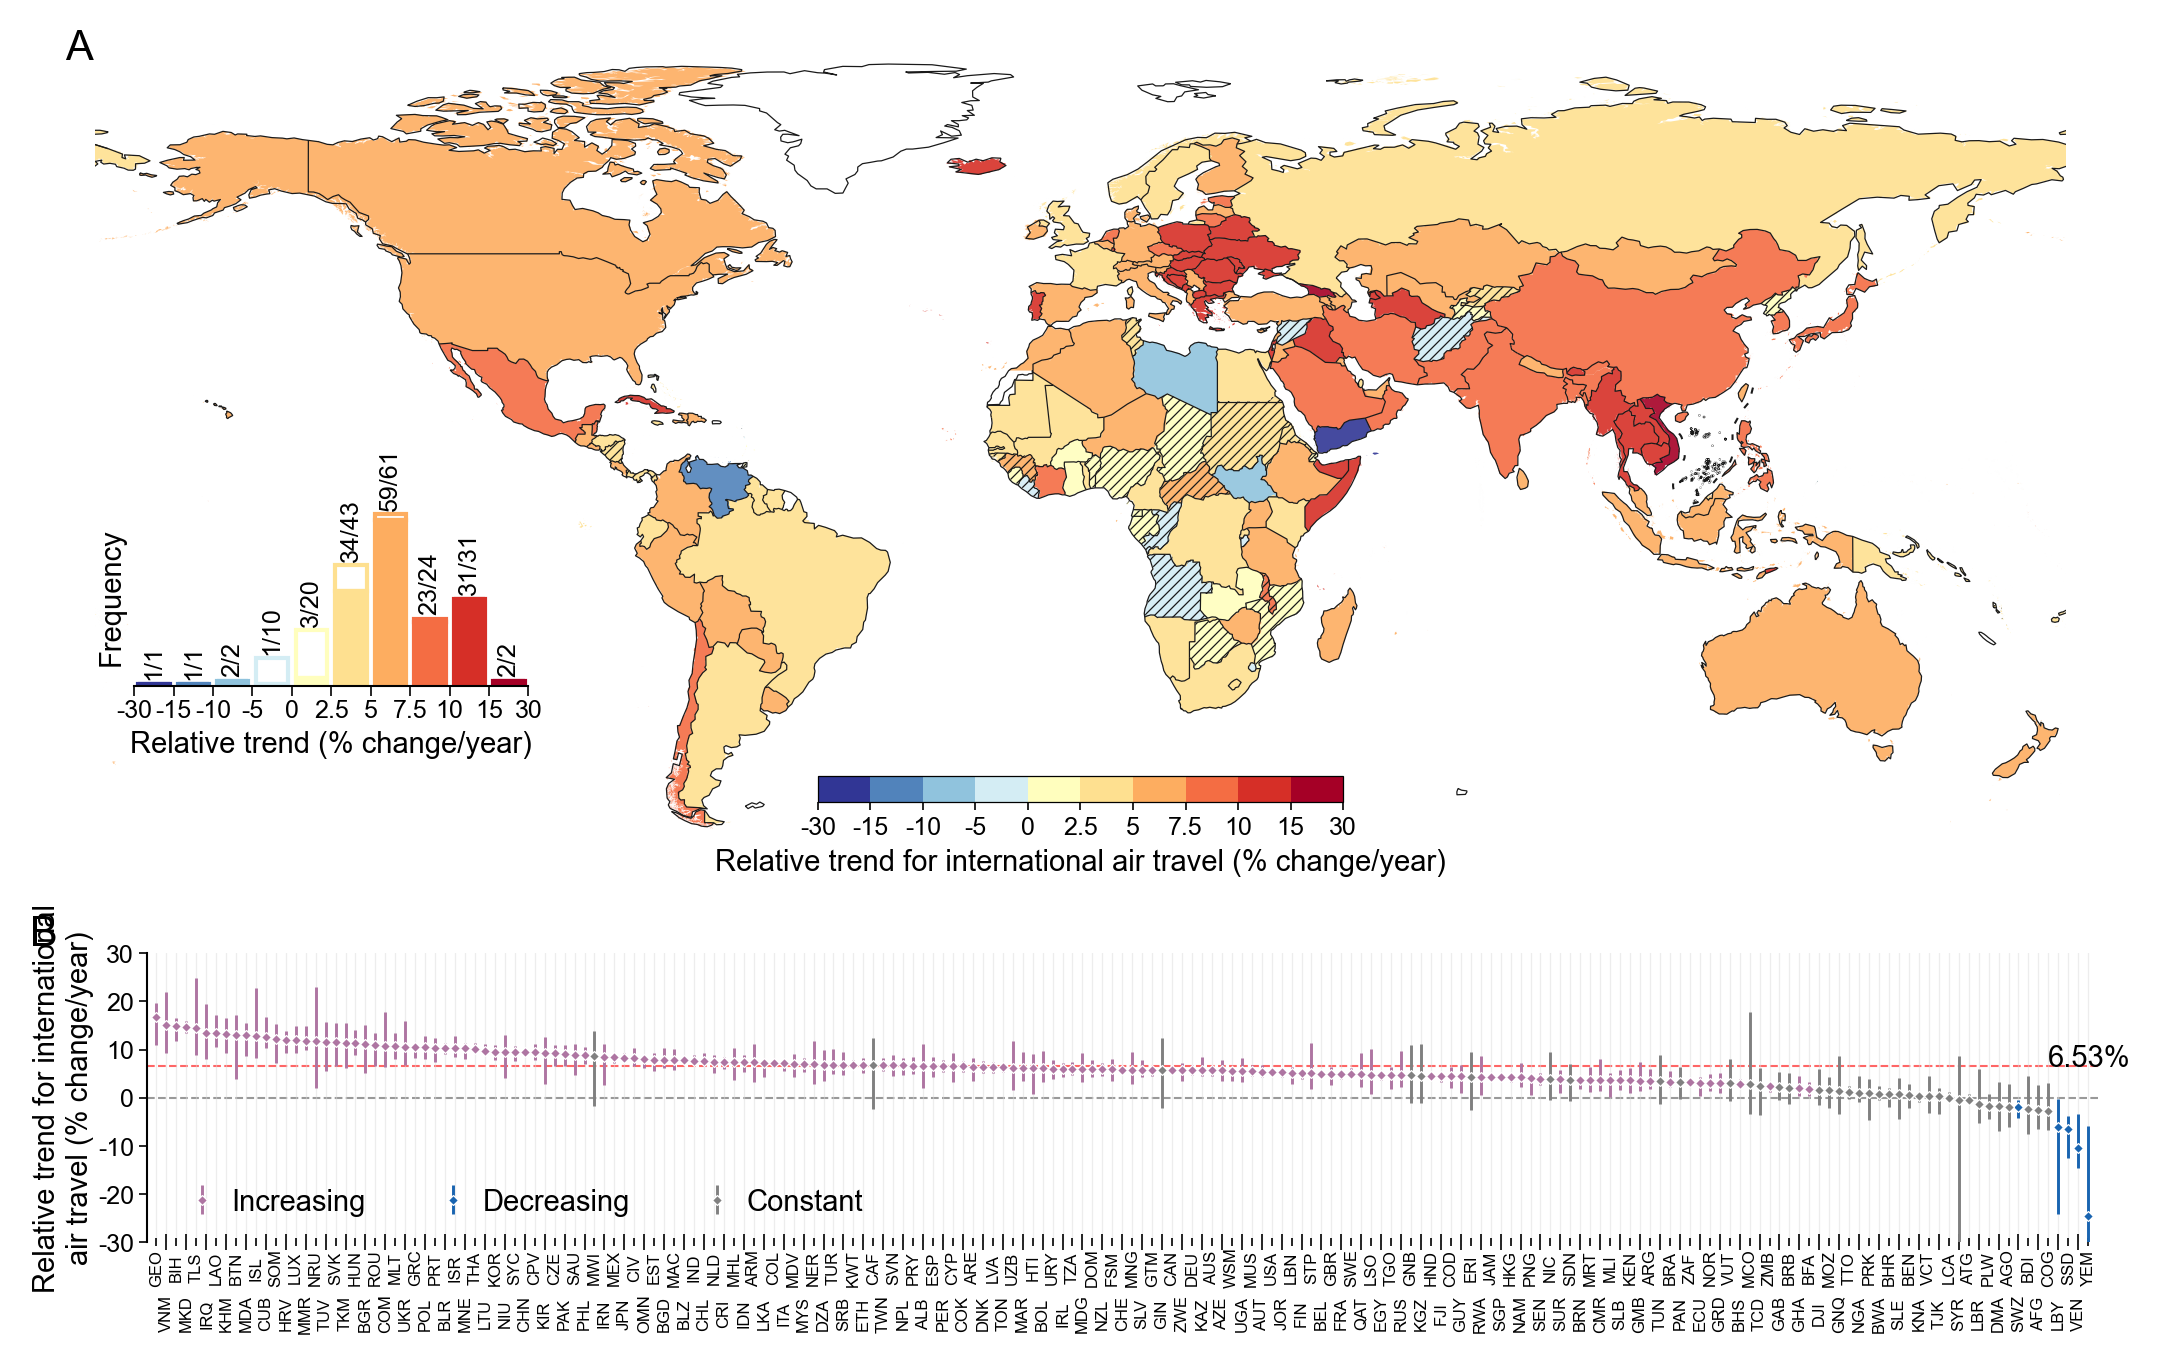

In [110]:
style = {
    "lines.linewidth": 0.5,
    "lines.markeredgewidth": 0.3,
    "font.size": 7.0,
    "font.family": "Arial",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.5,
    "axes.grid": False,
    "axes.labelsize": 7,
    "axes.labelpad": 2,
    "axes.labelweight": "normal",
    "axes.labelcolor": "black",
    "axes.xmargin": 0.01,
    "xtick.major.size": 2,
    "xtick.major.width": 0.4,
    "xtick.major.pad": 1.5,
    "ytick.major.size": 2,
    "ytick.major.width": 0.4,
    "ytick.major.pad": 1.5,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "hatch.linewidth": 0.1,
}

cbar_shrink = 0.3
cbar_pad = -0.1

cm = 1 / 2.54  # centimeters in inches

with mpl.rc_context(style):
    fig = plt.figure(
        layout="constrained", figsize=(18 * cm, (7.5 + 3.75) * cm), dpi=300
    )
    top, bottom = fig.subfigures(
        nrows=2, ncols=1, height_ratios=(7.5, 3.75), hspace=0.0, wspace=0.0
    )

    ax = top.add_subplot(111, projection=ccrs.PlateCarree())
    ax.text(
        0.0,
        1.0,
        "A",
        fontsize=10,
        transform=(
            ax.transAxes + ScaledTranslation(-7 / 72, 0 / 72, fig.dpi_scale_trans)
        ),
        va="top",
    )

    label = "international"
    df = national_int_traffic_trend.query("country in @countries_int")

    bins = np.array([-0.3, -0.15, -0.1, -0.05, 0, 0.025, 0.05, 0.075, 0.1, 0.15, 0.3])
    c1 = plt.cm.RdYlBu_r(np.linspace(0, 0.5, (bins < 0).sum(), endpoint=False))
    c2 = plt.cm.RdYlBu_r(np.linspace(0.5, 1, (bins > 0).sum()))
    cmap = ListedColormap(np.vstack([c1, c2]))
    norm = mcolors.BoundaryNorm(
        boundaries=bins, ncolors=len(bins) - 1, extend="neither"
    )

    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
    ax.set_axis_off()

    adm0_ = adm0.assign(
        var1=lambda x: x["alpha2"].map(df.set_index("country")["pct_slope"].to_dict())
    )
    ax.add_geometries(
        adm0_["geometry"].values,
        crs=ccrs.PlateCarree(),
        array=adm0_["var1"].values,
        cmap=cmap,
        norm=norm,
        alpha=0.9,
        rasterized=True,
    )

    codes = df.loc[df["trend"] == "no trend", "country"].values
    ax.add_geometries(
        adm0_.loc[adm0_["alpha2"].isin(codes), "geometry"].values,
        crs=ccrs.PlateCarree(),
        fc="none",
        ec=".1",
        lw=0.0,
        hatch="//////////",
        hatch_linewidth=0.3,
        alpha=1,
        rasterized=True,
    )
    ax.add_geometries(cn_south.geometry, ec='.1', fc='none',  lw=.5, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.LAND, facecolor="#FFFFFF", alpha=0.7, rasterized=True)

    ax_ = ax.inset_axes([0.02, 0.2, 0.2, 0.22])
    ct1 = pd.cut(
        df.query("country in @countries_int and trend != 'no trend'")["pct_slope"],
        bins=bins,
        ordered=True,
        right=False,
    ).value_counts(sort=False)
    ct2 = pd.cut(
        df.query("country in @countries_int and trend == 'no trend'")["pct_slope"],
        bins=bins,
        ordered=True,
        right=False,
    ).value_counts(sort=False)

    bars1 = ax_.bar(np.arange(len(ct1)), ct1.values)
    bars2 = ax_.bar(np.arange(len(ct2)), ct2.values, bottom=ct1.values)

    for i, (bar_1, bar_2) in enumerate(zip(bars1, bars2)):
        bar_1.set_fc(cmap(i / len(ct1)))
        bar_1.set_ec(cmap(i / len(ct1)))
        bar_2.set_fc("none")
        bar_2.set_ec(cmap(i / len(ct2)))

    for i, (ct1_, ct2_) in enumerate(zip(ct1, ct2)):
        ax_.text(
            i,
            ct1_ + ct2_ + 1.5,
            f"{ct1_}/{ct1_ + ct2_}",
            fontsize=6,
            va="bottom",
            ha="center",
            rotation=90,
        )

    ax_.tick_params(axis="both", size=2.5, pad=0.5)
    ax_.set_xticks(
        np.arange(len(bins)) - 0.5,
        labels=[
            f"{x * 100:.0f}" if x * 100 % 1 == 0 else f"{x * 100:.1f}" for x in bins
        ],
        fontsize=6,
        rotation=0,
    )
    ax_.set_yticks([])
    ax_.set_xlabel(r"Relative trend (% change/year)", fontsize=7)
    ax_.set_ylabel("Frequency", fontsize=7)
    ax_.spines[["top", "left", "right"]].set_visible(False)

    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(cmap=cmap),
        ax=ax,
        orientation="horizontal",
        shrink=0.25,
        pad=-0.08,
    )
    cbar.set_ticks(
        np.linspace(0, 1, len(bins)),
        labels=[
            f"{x * 100:.0f}" if x * 100 % 1 == 0 else f"{x * 100:.1f}" for x in bins
        ],
        fontsize=6,
    )
    cbar.set_label(
        f"Relative trend for {label} air travel" + r" (% change/year)", fontsize=7
    )
    cbar.ax.get_children()[6].set_lw(0.3)

    ax = bottom.add_subplot(111)
    ax.text(
        0.0,
        1.0,
        "B",
        fontsize=10,
        transform=(
            ax.transAxes + ScaledTranslation(-28 / 72, 0 / 72, fig.dpi_scale_trans)
        ),
        va="bottom",
    )

    tmp1 = national_int_traffic_trend.query("country in @countries_int").sort_values(
        "pct_slope", ascending=False
    )
    lb = tmp1["pct_slope_low"].values
    ub = tmp1["pct_slope_high"].values
    md = tmp1["pct_slope"].values
    nobs = len(tmp1)
    sigi = (tmp1["trend"] == "increasing").values
    sigd = (tmp1["trend"] == "decreasing").values
    sign = (tmp1["trend"] == "no trend").values

    ax.errorbar(
        x=np.arange(nobs)[sigi],
        y=md[sigi],
        yerr=np.vstack([md - lb, ub - md])[:, sigi],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="#AE75A2",
        ecolor="#AE75A2",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="Increasing",
    )
    ax.errorbar(
        x=np.arange(nobs)[sigd],
        y=md[sigd],
        yerr=np.vstack([md - lb, ub - md])[:, sigd],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="#1964B0",
        ecolor="#1964B0",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="Decreasing",
    )
    ax.errorbar(
        x=np.arange(nobs)[sign],
        y=md[sign],
        yerr=np.vstack([md - lb, ub - md])[:, sign],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="gray",
        ecolor="gray",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="Constant",
    )

    ax.axhline(y=0, ls="--", color="gray", alpha=0.8, zorder=-99, lw=0.5)
    ax.axhline(y=global_int_trend, ls="--", color="r", alpha=0.6, zorder=-99, lw=0.5)
    
    ax.text(
        190,
        global_int_trend,
        f"{global_int_trend:.2%}",
    )

    ax.legend(
        loc="lower left",
        fontsize=7,
        frameon=False,
        handletextpad=0,
        labelspacing=0,
        ncols=3,
    )

    ax.set_ylim(-0.3, 0.3)
    ax.set_xmargin(0.005)

    ax.set_yticks([-0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3])
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x * 100:.0f}")
    ax.tick_params(axis="y", labelsize=6, size=2, width=0.4, pad=1)

    ax.set_xticks(
        np.arange(nobs)[::2],
        [iso2_to_iso3[x] for x in tmp1["country"].values[::2]],
        fontsize=4.0,
        rotation_mode="default",
        va="center",
        ha="center",
        rotation=90,
    )
    ax.set_xticks(
        np.arange(nobs)[1::2],
        [iso2_to_iso3[x] for x in tmp1["country"].values[1::2]],
        minor=True,
        fontsize=4.0,
        rotation_mode="default",
        va="center",
        ha="center",
        rotation=90,
    )

    ax.tick_params(
        axis="x",
        which="major",
        direction="inout",
        size=2,
        width=0.4,
        pad=5,
        top=False,
        bottom=True,
    )
    ax.tick_params(
        axis="x",
        which="minor",
        direction="inout",
        size=4,
        width=0.4,
        pad=15,
        top=False,
        bottom=True,
        labelbottom=True,
        labeltop=False,
    )

    ax.grid(axis="x", which="both", lw=0.3, color="#DCDCDC", alpha=0.5)

    ax.set_ylabel(
        "Relative trend for international\nair travel (% change/year)", fontsize=7, labelpad=1
    )
    # ax.set_xlabel("Country", fontsize=5)
    ax.spines[["top", "right", "bottom"]].set_visible(False)

    # plot_children(fig)
    plt.savefig("./Fig3ab_0608.pdf")
    plt.show()

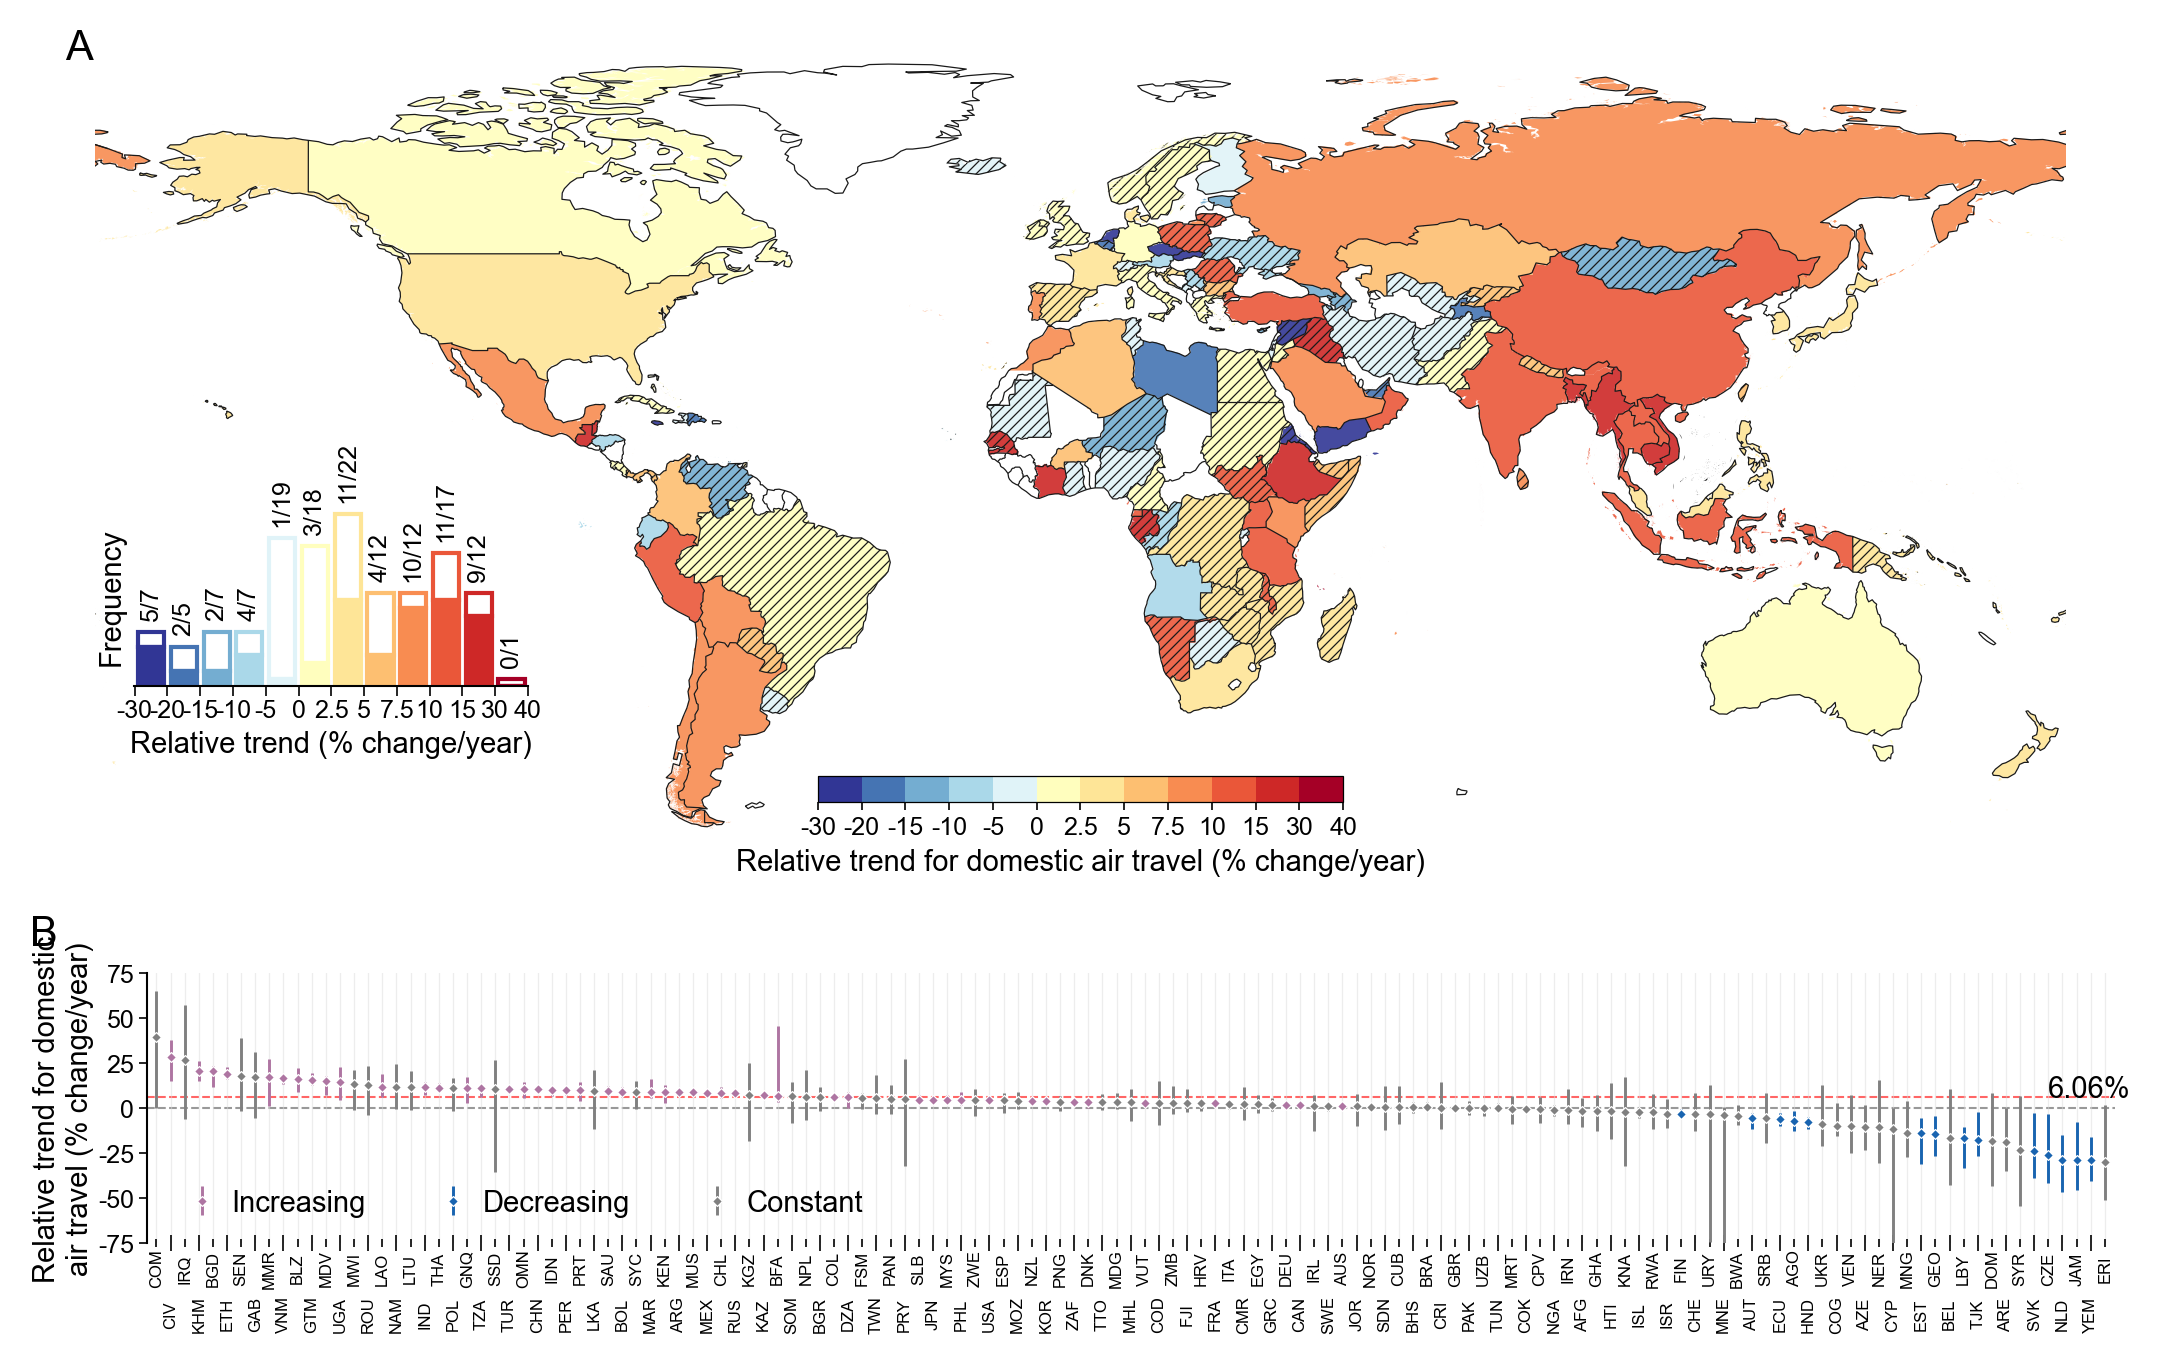

In [112]:
with mpl.rc_context(style):

    fig = plt.figure(
        layout="constrained", figsize=(18 * cm, (7.5 + 3.75) * cm), dpi=300
    )
    top, bottom = fig.subfigures(
        nrows=2, ncols=1, height_ratios=(7.5, 3.75), hspace=0.0, wspace=0.0
    )

    ax = top.add_subplot(111, projection=ccrs.PlateCarree())
    ax.text(
        0.0,
        1.0,
        "A",
        fontsize=10,
        transform=(
            ax.transAxes + ScaledTranslation(-7 / 72, 0 / 72, fig.dpi_scale_trans)
        ),
        va="top",
    )

    label = "domestic"
    df = national_dom_traffic_trend.query("country in @countries_dom")

    bins = np.array(
        [-0.3, -0.2, -0.15, -0.1, -0.05, 0, 0.025, 0.05, 0.075, 0.1, 0.15, 0.3, 0.4]
    )
    c1 = plt.cm.RdYlBu_r(np.linspace(0, 0.5, (bins < 0).sum(), endpoint=False))
    c2 = plt.cm.RdYlBu_r(np.linspace(0.5, 1, (bins > 0).sum()))
    cmap = ListedColormap(np.vstack([c1, c2]))
    norm = mcolors.BoundaryNorm(
        boundaries=bins, ncolors=len(bins) - 1, extend="neither"
    )

    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
    ax.set_axis_off()

    adm0_ = adm0.assign(
        var1=lambda x: x["alpha2"].map(df.set_index("country")["pct_slope"].to_dict())
    ).query("alpha2 in @countries_dom")
    ax.add_geometries(
        adm0_["geometry"].values,
        crs=ccrs.PlateCarree(),
        array=adm0_["var1"].values,
        cmap=cmap,
        norm=norm,
        alpha=0.9,
        rasterized=True,
    )

    codes = df.loc[df["trend"] == "no trend", "country"].values
    ax.add_geometries(
        adm0_.loc[adm0_["alpha2"].isin(codes), "geometry"].values,
        crs=ccrs.PlateCarree(),
        fc="none",
        ec=".1",
        lw=0.0,
        hatch="//////////",
        hatch_linewidth=0.3,
        alpha=1,
        rasterized=True,
    )
    ax.add_geometries(cn_south.geometry, lw=.5, ec='none', fc='.1', crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.LAND, facecolor="#FFFFFF", alpha=0.7, rasterized=True)

    ax_ = ax.inset_axes([0.02, 0.2, 0.2, 0.22])
    ct1 = pd.cut(
        df.query("country in @countries_dom and trend != 'no trend'")["pct_slope"],
        bins=bins,
        ordered=True,
        right=False,
    ).value_counts(sort=False)
    ct2 = pd.cut(
        df.query("country in @countries_dom and trend == 'no trend'")["pct_slope"],
        bins=bins,
        ordered=True,
        right=False,
    ).value_counts(sort=False)

    bars1 = ax_.bar(np.arange(len(ct1)), ct1.values)
    bars2 = ax_.bar(np.arange(len(ct2)), ct2.values, bottom=ct1.values)

    for i, (bar_1, bar_2) in enumerate(zip(bars1, bars2)):
        bar_1.set_fc(cmap(i / len(ct1)))
        bar_1.set_ec(cmap(i / len(ct1)))
        bar_2.set_fc("none")
        bar_2.set_ec(cmap(i / len(ct2)))

    for i, (ct1_, ct2_) in enumerate(zip(ct1, ct2)):
        ax_.text(
            i,
            ct1_ + ct2_ + 1.5,
            f"{ct1_}/{ct1_ + ct2_}",
            fontsize=6,
            va="bottom",
            ha="center",
            rotation=90,
        )

    ax_.tick_params(axis="both", size=2.5, pad=0.5)
    ax_.set_xticks(
        np.arange(len(bins)) - 0.5,
        labels=[
            f"{x * 100:.0f}" if x * 100 % 1 == 0 else f"{x * 100:.1f}" for x in bins
        ],
        fontsize=6,
        rotation=0,
    )
    ax_.set_yticks([])
    ax_.set_xlabel(r"Relative trend (% change/year)", fontsize=7)
    ax_.set_ylabel("Frequency", fontsize=7)
    ax_.spines[["top", "left", "right"]].set_visible(False)

    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(cmap=cmap),
        ax=ax,
        orientation="horizontal",
        shrink=0.25,
        pad=-0.08,
    )
    cbar.set_ticks(
        np.linspace(0, 1, len(bins)),
        labels=[
            f"{x * 100:.0f}" if x * 100 % 1 == 0 else f"{x * 100:.1f}" for x in bins
        ],
        fontsize=6,
    )
    cbar.set_label(
        f"Relative trend for {label} air travel" + r" (% change/year)", fontsize=7
    )
    cbar.ax.get_children()[6].set_lw(0.3)

    ax = bottom.add_subplot(111)
    ax.text(
        0.0,
        1.0,
        "B",
        fontsize=10,
        transform=(
            ax.transAxes + ScaledTranslation(-28 / 72, 14 / 72, fig.dpi_scale_trans)
        ),
        va="top",
    )

    tmp1 = national_dom_traffic_trend.query("country in @countries_dom").sort_values(
        "pct_slope", ascending=False
    )
    lb = tmp1["pct_slope_low"].values
    ub = tmp1["pct_slope_high"].values
    md = tmp1["pct_slope"].values
    nobs = len(tmp1)
    sigi = (tmp1["trend"] == "increasing").values
    sigd = (tmp1["trend"] == "decreasing").values
    sign = (tmp1["trend"] == "no trend").values

    ax.errorbar(
        x=np.arange(nobs)[sigi],
        y=md[sigi],
        yerr=np.vstack([md - lb, ub - md])[:, sigi],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="#AE75A2",
        ecolor="#AE75A2",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="Increasing",
    )
    ax.errorbar(
        x=np.arange(nobs)[sigd],
        y=md[sigd],
        yerr=np.vstack([md - lb, ub - md])[:, sigd],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="#1964B0",
        ecolor="#1964B0",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="Decreasing",
    )
    ax.errorbar(
        x=np.arange(nobs)[sign],
        y=md[sign],
        yerr=np.vstack([md - lb, ub - md])[:, sign],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="gray",
        ecolor="gray",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="Constant",
    )

    ax.axhline(y=0, ls="--", color="gray", alpha=0.8, zorder=-99, lw=0.5)
    ax.axhline(y=global_dom_trend, ls="--", color="r", alpha=0.6, zorder=-99, lw=0.5)
    ax.text(
        134,
        global_dom_trend,
        f"{global_dom_trend:.2%}",
    )

    ax.legend(
        loc="lower left",
        fontsize=7,
        frameon=False,
        handletextpad=0,
        labelspacing=0,
        ncols=3,
    )

    ax.set_ylim(-0.75, 0.75)
    ax.set_xmargin(0.005)

    ax.set_yticks([-0.75, -0.5, -0.25, 0, 0.25, 0.50, 0.75])
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x * 100:.0f}")
    ax.tick_params(axis="y", labelsize=6, size=2, width=0.4, pad=1)

    ax.set_xticks(
        np.arange(nobs)[::2],
        [iso2_to_iso3[x] for x in tmp1["country"].values[::2]],
        fontsize=4.0,
        rotation_mode="default",
        va="center",
        ha="center",
        rotation=90,
    )
    ax.set_xticks(
        np.arange(nobs)[1::2],
        [iso2_to_iso3[x] for x in tmp1["country"].values[1::2]],
        minor=True,
        fontsize=4.0,
        rotation_mode="default",
        va="center",
        ha="center",
        rotation=90,
    )

    ax.tick_params(
        axis="x",
        which="major",
        direction="inout",
        size=2,
        width=0.4,
        pad=5,
        top=False,
        bottom=True,
    )
    ax.tick_params(
        axis="x",
        which="minor",
        direction="inout",
        size=4,
        width=0.4,
        pad=15,
        top=False,
        bottom=True,
        labelbottom=True,
        labeltop=False,
    )

    ax.grid(axis="x", which="both", lw=0.3, color="#DCDCDC", alpha=0.5)

    ax.set_ylabel(
        "Relative trend for domestic\nair travel (% change/year)", fontsize=7, labelpad=1
    )
    # ax.set_xlabel("Country", fontsize=5)
    ax.spines[["top", "right", "bottom"]].set_visible(False)

    # plot_children(fig)
    plt.savefig("./Fig4ab_0608.pdf")
    plt.show()

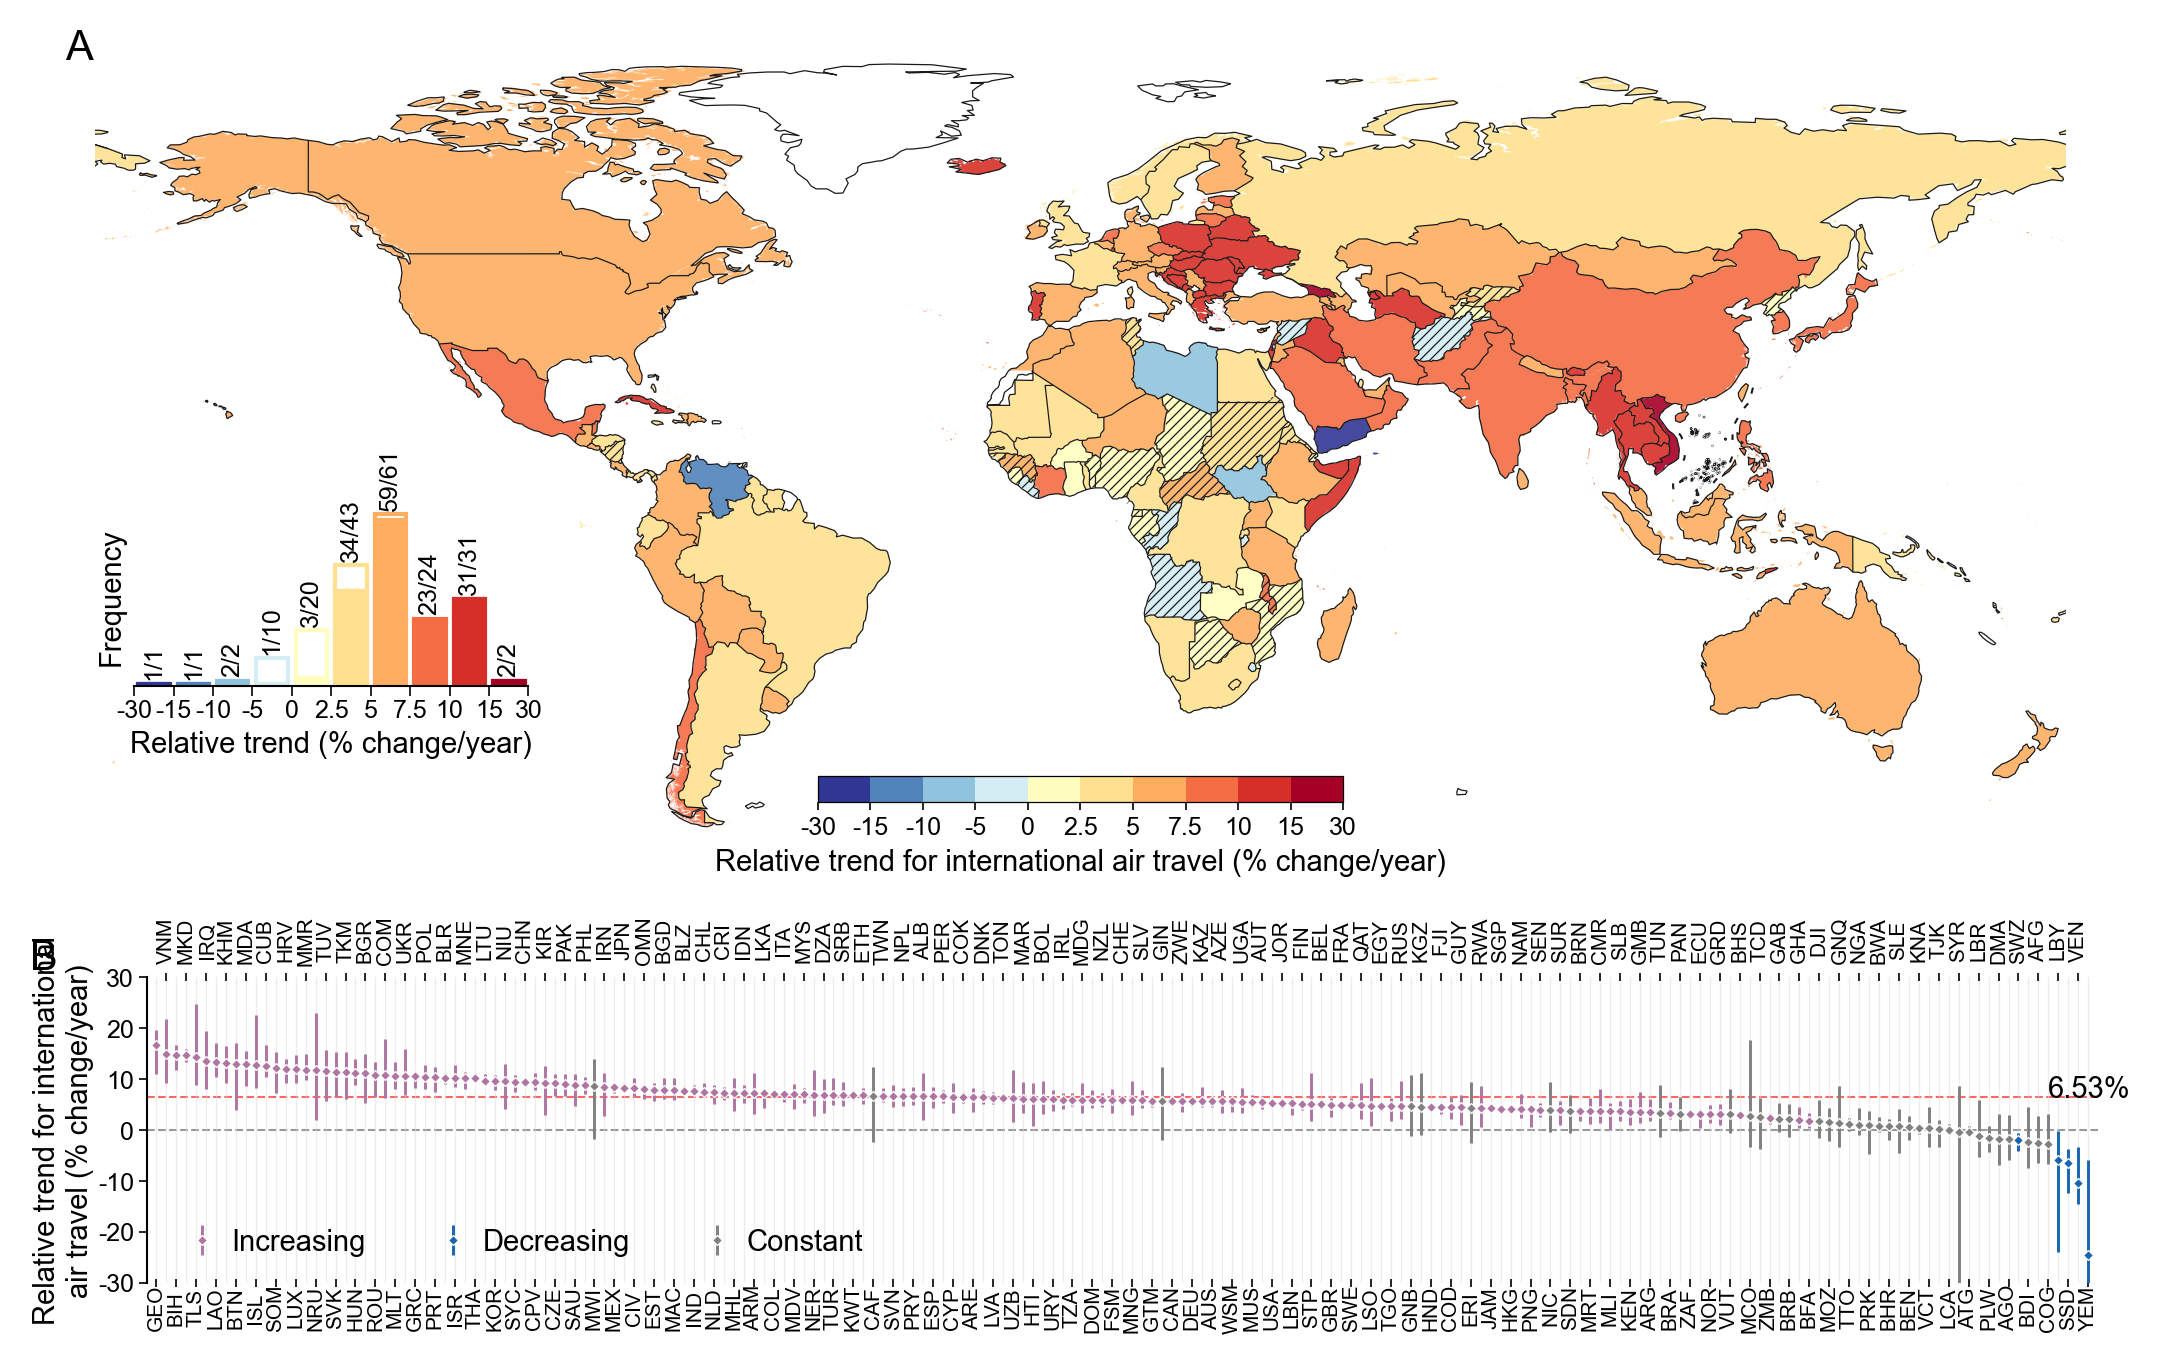

In [108]:
style = {
    "lines.linewidth": 0.5,
    "lines.markeredgewidth": 0.3,
    "font.size": 7.0,
    "font.family": "Arial",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.5,
    "axes.grid": False,
    "axes.labelsize": 7,
    "axes.labelpad": 2,
    "axes.labelweight": "normal",
    "axes.labelcolor": "black",
    "axes.xmargin": 0.01,
    "xtick.major.size": 2,
    "xtick.major.width": 0.4,
    "xtick.major.pad": 1.5,
    "ytick.major.size": 2,
    "ytick.major.width": 0.4,
    "ytick.major.pad": 1.5,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "hatch.linewidth": 0.1,
}

cbar_shrink = 0.3
cbar_pad = -0.1

cm = 1 / 2.54  # centimeters in inches

with mpl.rc_context(style):
    fig = plt.figure(
        layout="constrained", figsize=(18 * cm, (7.5 + 3.75) * cm), dpi=300
    )
    top, bottom = fig.subfigures(
        nrows=2, ncols=1, height_ratios=(7.5, 3.75), hspace=0.0, wspace=0.0
    )

    ax = top.add_subplot(111, projection=ccrs.PlateCarree())
    ax.text(
        0.0,
        1.0,
        "A",
        fontsize=10,
        transform=(
            ax.transAxes + ScaledTranslation(-7 / 72, 0 / 72, fig.dpi_scale_trans)
        ),
        va="top",
    )

    label = "international"
    df = national_int_traffic_trend.query("country in @countries_int")

    bins = np.array([-0.3, -0.15, -0.1, -0.05, 0, 0.025, 0.05, 0.075, 0.1, 0.15, 0.3])
    c1 = plt.cm.RdYlBu_r(np.linspace(0, 0.5, (bins < 0).sum(), endpoint=False))
    c2 = plt.cm.RdYlBu_r(np.linspace(0.5, 1, (bins > 0).sum()))
    cmap = ListedColormap(np.vstack([c1, c2]))
    norm = mcolors.BoundaryNorm(
        boundaries=bins, ncolors=len(bins) - 1, extend="neither"
    )

    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
    ax.set_axis_off()

    adm0_ = adm0.assign(
        var1=lambda x: x["alpha2"].map(df.set_index("country")["pct_slope"].to_dict())
    )
    ax.add_geometries(
        adm0_["geometry"].values,
        crs=ccrs.PlateCarree(),
        array=adm0_["var1"].values,
        cmap=cmap,
        norm=norm,
        alpha=0.9,
        rasterized=True,
    )

    codes = df.loc[df["trend"] == "no trend", "country"].values
    ax.add_geometries(
        adm0_.loc[adm0_["alpha2"].isin(codes), "geometry"].values,
        crs=ccrs.PlateCarree(),
        fc="none",
        ec=".1",
        lw=0.0,
        hatch="//////////",
        hatch_linewidth=0.3,
        alpha=1,
        rasterized=True,
    )
    ax.add_geometries(cn_south.geometry, ec='.1', fc='none',  lw=.5, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.LAND, facecolor="#FFFFFF", alpha=0.7, rasterized=True)

    ax_ = ax.inset_axes([0.02, 0.2, 0.2, 0.22])
    ct1 = pd.cut(
        df.query("country in @countries_int and trend != 'no trend'")["pct_slope"],
        bins=bins,
        ordered=True,
        right=False,
    ).value_counts(sort=False)
    ct2 = pd.cut(
        df.query("country in @countries_int and trend == 'no trend'")["pct_slope"],
        bins=bins,
        ordered=True,
        right=False,
    ).value_counts(sort=False)

    bars1 = ax_.bar(np.arange(len(ct1)), ct1.values)
    bars2 = ax_.bar(np.arange(len(ct2)), ct2.values, bottom=ct1.values)

    for i, (bar_1, bar_2) in enumerate(zip(bars1, bars2)):
        bar_1.set_fc(cmap(i / len(ct1)))
        bar_1.set_ec(cmap(i / len(ct1)))
        bar_2.set_fc("none")
        bar_2.set_ec(cmap(i / len(ct2)))

    for i, (ct1_, ct2_) in enumerate(zip(ct1, ct2)):
        ax_.text(
            i,
            ct1_ + ct2_ + 1.5,
            f"{ct1_}/{ct1_ + ct2_}",
            fontsize=6,
            va="bottom",
            ha="center",
            rotation=90,
        )

    ax_.tick_params(axis="both", size=2.5, pad=0.5)
    ax_.set_xticks(
        np.arange(len(bins)) - 0.5,
        labels=[
            f"{x * 100:.0f}" if x * 100 % 1 == 0 else f"{x * 100:.1f}" for x in bins
        ],
        fontsize=6,
        rotation=0,
    )
    ax_.set_yticks([])
    ax_.set_xlabel(r"Relative trend (% change/year)", fontsize=7)
    ax_.set_ylabel("Frequency", fontsize=7)
    ax_.spines[["top", "left", "right"]].set_visible(False)

    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(cmap=cmap),
        ax=ax,
        orientation="horizontal",
        shrink=0.25,
        pad=-0.08,
    )
    cbar.set_ticks(
        np.linspace(0, 1, len(bins)),
        labels=[
            f"{x * 100:.0f}" if x * 100 % 1 == 0 else f"{x * 100:.1f}" for x in bins
        ],
        fontsize=6,
    )
    cbar.set_label(
        f"Relative trend for {label} air travel" + r" (% change/year)", fontsize=7
    )
    cbar.ax.get_children()[6].set_lw(0.3)

    ax = bottom.add_subplot(111)
    ax.text(
        0.0,
        1.0,
        "B",
        fontsize=10,
        transform=(
            ax.transAxes + ScaledTranslation(-28 / 72, 0 / 72, fig.dpi_scale_trans)
        ),
        va="bottom",
    )

    tmp1 = national_int_traffic_trend.query("country in @countries_int").sort_values(
        "pct_slope", ascending=False
    )
    lb = tmp1["pct_slope_low"].values
    ub = tmp1["pct_slope_high"].values
    md = tmp1["pct_slope"].values
    nobs = len(tmp1)
    sigi = (tmp1["trend"] == "increasing").values
    sigd = (tmp1["trend"] == "decreasing").values
    sign = (tmp1["trend"] == "no trend").values

    ax.errorbar(
        x=np.arange(nobs)[sigi],
        y=md[sigi],
        yerr=np.vstack([md - lb, ub - md])[:, sigi],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="#AE75A2",
        ecolor="#AE75A2",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="Increasing",
    )
    ax.errorbar(
        x=np.arange(nobs)[sigd],
        y=md[sigd],
        yerr=np.vstack([md - lb, ub - md])[:, sigd],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="#1964B0",
        ecolor="#1964B0",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="Decreasing",
    )
    ax.errorbar(
        x=np.arange(nobs)[sign],
        y=md[sign],
        yerr=np.vstack([md - lb, ub - md])[:, sign],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="gray",
        ecolor="gray",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="Constant",
    )

    ax.axhline(y=0, ls="--", color="gray", alpha=0.8, zorder=-99, lw=0.5)
    ax.axhline(y=global_int_trend, ls="--", color="r", alpha=0.6, zorder=-99, lw=0.5)
    
    ax.text(
        190,
        global_int_trend,
        f"{global_int_trend:.2%}",
    )

    ax.legend(
        loc="lower left",
        fontsize=7,
        frameon=False,
        handletextpad=0,
        labelspacing=0,
        ncols=3,
    )

    ax.set_ylim(-0.3, 0.3)
    ax.set_xmargin(0.005)

    ax.set_yticks([-0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3])
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x * 100:.0f}")
    ax.tick_params(axis="y", labelsize=6, size=2, width=0.4, pad=1)

    ax.set_xticks(
        np.arange(nobs)[::2],
        [iso2_to_iso3[x] for x in tmp1["country"].values[::2]],
        fontsize=5.0,
        rotation_mode="default",
        va="center",
        ha="center",
        rotation=90,
    )
    ax.set_xticks(
        np.arange(nobs)[1::2],
        [iso2_to_iso3[x] for x in tmp1["country"].values[1::2]],
        minor=True,
        fontsize=5.0,
        rotation_mode="default",
        va="center",
        ha="center",
        rotation=90,
    )

    ax.tick_params(
        axis="x",
        which="major",
        direction="inout",
        size=2,
        width=0.4,
        pad=5,
        top=False,
        bottom=True,
    )
    ax.tick_params(
        axis="x",
        which="minor",
        direction="inout",
        size=2,
        width=0.4,
        pad=8,
        top=True,
        bottom=False,
        labelbottom=False,
        labeltop=True,
    )

    ax.grid(axis="x", which="both", lw=0.3, color="#DCDCDC", alpha=0.5)

    ax.set_ylabel(
        "Relative trend for international\nair travel (% change/year)", fontsize=7, labelpad=1
    )
    # ax.set_xlabel("Country", fontsize=5)
    ax.spines[["top", "right", "bottom"]].set_visible(False)

    # plot_children(fig)
    plt.savefig("./Fig3ab_0608.pdf")
    plt.show()

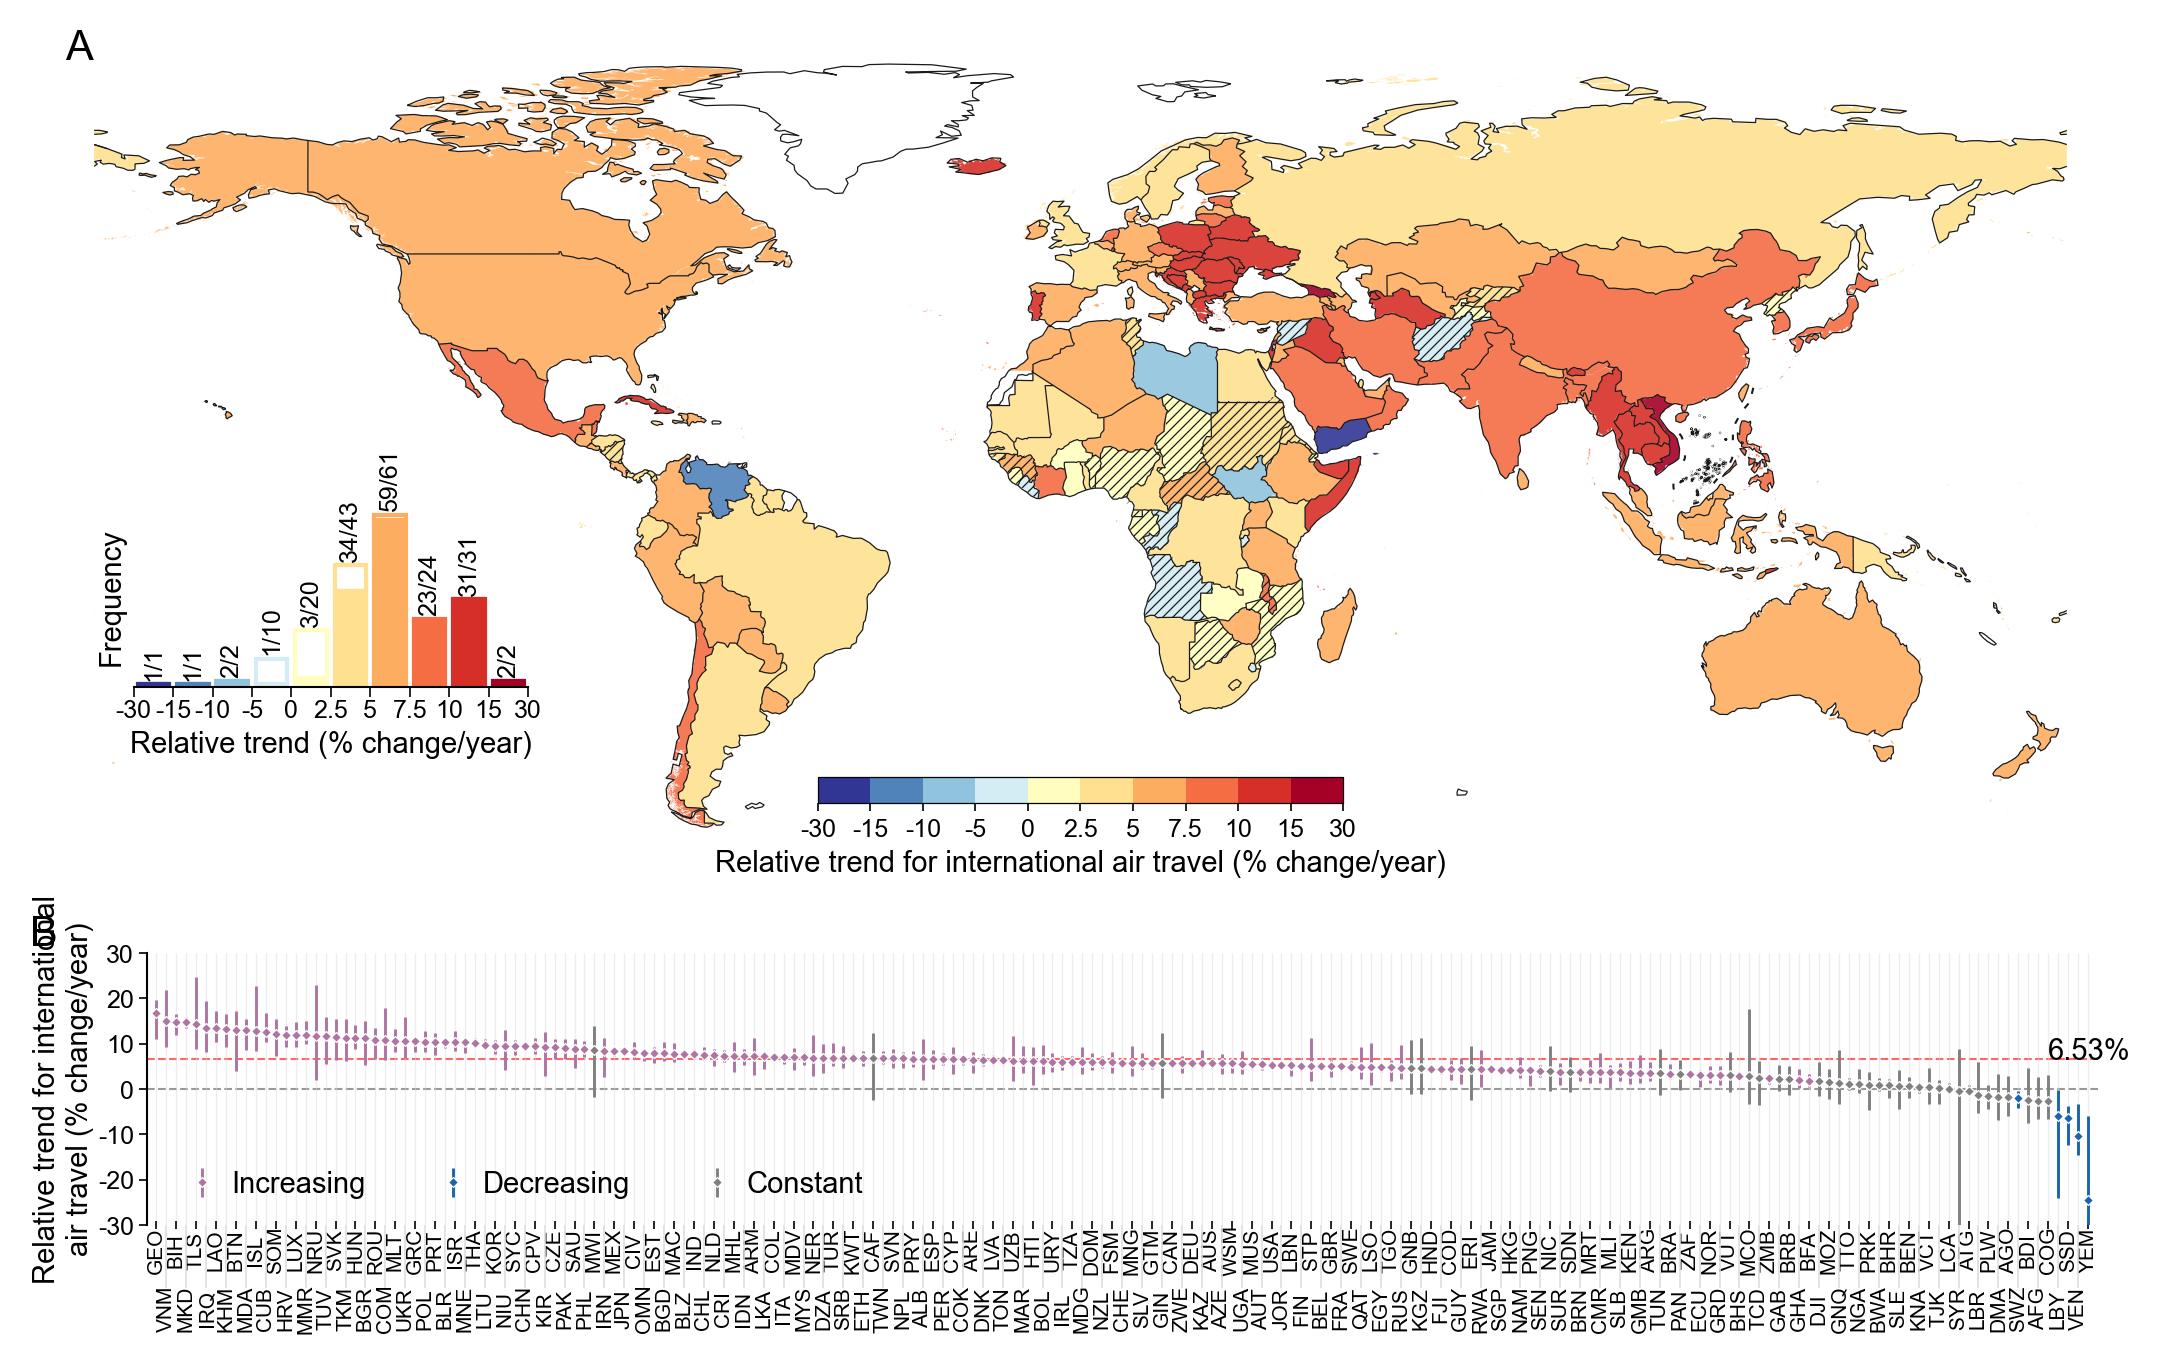

In [ ]:
style = {
    "lines.linewidth": 0.5,
    "lines.markeredgewidth": 0.3,
    "font.size": 7.0,
    "font.family": "Arial",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.5,
    "axes.grid": False,
    "axes.labelsize": 7,
    "axes.labelpad": 2,
    "axes.labelweight": "normal",
    "axes.labelcolor": "black",
    "axes.xmargin": 0.01,
    "xtick.major.size": 2,
    "xtick.major.width": 0.4,
    "xtick.major.pad": 1.5,
    "ytick.major.size": 2,
    "ytick.major.width": 0.4,
    "ytick.major.pad": 1.5,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "hatch.linewidth": 0.1,
}

cbar_shrink = 0.3
cbar_pad = -0.1

cm = 1 / 2.54  # centimeters in inches

with mpl.rc_context(style):
    fig = plt.figure(
        layout="constrained", figsize=(18 * cm, (7.5 + 3.75) * cm), dpi=300
    )
    top, bottom = fig.subfigures(
        nrows=2, ncols=1, height_ratios=(7.5, 3.75), hspace=0.0, wspace=0.0
    )

    ax = top.add_subplot(111, projection=ccrs.PlateCarree())
    ax.text(
        0.0,
        1.0,
        "A",
        fontsize=10,
        transform=(
            ax.transAxes + ScaledTranslation(-7 / 72, 0 / 72, fig.dpi_scale_trans)
        ),
        va="top",
    )

    label = "international"
    df = national_int_traffic_trend.query("country in @countries_int")

    bins = np.array([-0.3, -0.15, -0.1, -0.05, 0, 0.025, 0.05, 0.075, 0.1, 0.15, 0.3])
    c1 = plt.cm.RdYlBu_r(np.linspace(0, 0.5, (bins < 0).sum(), endpoint=False))
    c2 = plt.cm.RdYlBu_r(np.linspace(0.5, 1, (bins > 0).sum()))
    cmap = ListedColormap(np.vstack([c1, c2]))
    norm = mcolors.BoundaryNorm(
        boundaries=bins, ncolors=len(bins) - 1, extend="neither"
    )

    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
    ax.set_axis_off()

    adm0_ = adm0.assign(
        var1=lambda x: x["alpha2"].map(df.set_index("country")["pct_slope"].to_dict())
    )
    ax.add_geometries(
        adm0_["geometry"].values,
        crs=ccrs.PlateCarree(),
        array=adm0_["var1"].values,
        cmap=cmap,
        norm=norm,
        alpha=0.9,
        rasterized=True,
    )

    codes = df.loc[df["trend"] == "no trend", "country"].values
    ax.add_geometries(
        adm0_.loc[adm0_["alpha2"].isin(codes), "geometry"].values,
        crs=ccrs.PlateCarree(),
        fc="none",
        ec=".1",
        lw=0.0,
        hatch="//////////",
        hatch_linewidth=0.3,
        alpha=1,
        rasterized=True,
    )
    ax.add_geometries(cn_south.geometry, ec='.1', fc='none',  lw=.5, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.LAND, facecolor="#FFFFFF", alpha=0.7, rasterized=True)

    ax_ = ax.inset_axes([0.02, 0.2, 0.2, 0.22])
    ct1 = pd.cut(
        df.query("country in @countries_int and trend != 'no trend'")["pct_slope"],
        bins=bins,
        ordered=True,
        right=False,
    ).value_counts(sort=False)
    ct2 = pd.cut(
        df.query("country in @countries_int and trend == 'no trend'")["pct_slope"],
        bins=bins,
        ordered=True,
        right=False,
    ).value_counts(sort=False)

    bars1 = ax_.bar(np.arange(len(ct1)), ct1.values)
    bars2 = ax_.bar(np.arange(len(ct2)), ct2.values, bottom=ct1.values)

    for i, (bar_1, bar_2) in enumerate(zip(bars1, bars2)):
        bar_1.set_fc(cmap(i / len(ct1)))
        bar_1.set_ec(cmap(i / len(ct1)))
        bar_2.set_fc("none")
        bar_2.set_ec(cmap(i / len(ct2)))

    for i, (ct1_, ct2_) in enumerate(zip(ct1, ct2)):
        ax_.text(
            i,
            ct1_ + ct2_ + 1.5,
            f"{ct1_}/{ct1_ + ct2_}",
            fontsize=6,
            va="bottom",
            ha="center",
            rotation=90,
        )

    ax_.tick_params(axis="both", size=2.5, pad=0.5)
    ax_.set_xticks(
        np.arange(len(bins)) - 0.5,
        labels=[
            f"{x * 100:.0f}" if x * 100 % 1 == 0 else f"{x * 100:.1f}" for x in bins
        ],
        fontsize=6,
        rotation=0,
    )
    ax_.set_yticks([])
    ax_.set_xlabel(r"Relative trend (% change/year)", fontsize=7)
    ax_.set_ylabel("Frequency", fontsize=7)
    ax_.spines[["top", "left", "right"]].set_visible(False)

    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(cmap=cmap),
        ax=ax,
        orientation="horizontal",
        shrink=0.25,
        pad=-0.08,
    )
    cbar.set_ticks(
        np.linspace(0, 1, len(bins)),
        labels=[
            f"{x * 100:.0f}" if x * 100 % 1 == 0 else f"{x * 100:.1f}" for x in bins
        ],
        fontsize=6,
    )
    cbar.set_label(
        f"Relative trend for {label} air travel" + r" (% change/year)", fontsize=7
    )
    cbar.ax.get_children()[6].set_lw(0.3)

    ax = bottom.add_subplot(111)
    ax.text(
        0.0,
        1.0,
        "B",
        fontsize=10,
        transform=(
            ax.transAxes + ScaledTranslation(-28 / 72, 0 / 72, fig.dpi_scale_trans)
        ),
        va="bottom",
    )

    tmp1 = national_int_traffic_trend.query("country in @countries_int").sort_values(
        "pct_slope", ascending=False
    )
    lb = tmp1["pct_slope_low"].values
    ub = tmp1["pct_slope_high"].values
    md = tmp1["pct_slope"].values
    nobs = len(tmp1)
    sigi = (tmp1["trend"] == "increasing").values
    sigd = (tmp1["trend"] == "decreasing").values
    sign = (tmp1["trend"] == "no trend").values

    ax.errorbar(
        x=np.arange(nobs)[sigi],
        y=md[sigi],
        yerr=np.vstack([md - lb, ub - md])[:, sigi],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="#AE75A2",
        ecolor="#AE75A2",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="Increasing",
    )
    ax.errorbar(
        x=np.arange(nobs)[sigd],
        y=md[sigd],
        yerr=np.vstack([md - lb, ub - md])[:, sigd],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="#1964B0",
        ecolor="#1964B0",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="Decreasing",
    )
    ax.errorbar(
        x=np.arange(nobs)[sign],
        y=md[sign],
        yerr=np.vstack([md - lb, ub - md])[:, sign],
        fmt="D",
        ms=1.7,
        mew=0.3,
        mec="white",
        mfc="gray",
        ecolor="gray",
        elinewidth=0.7,
        capsize=0.0,
        capthick=0.5,
        label="Constant",
    )

    ax.axhline(y=0, ls="--", color="gray", alpha=0.8, zorder=-99, lw=0.5)
    ax.axhline(y=global_int_trend, ls="--", color="r", alpha=0.6, zorder=-99, lw=0.5)
    
    ax.text(
        190,
        global_int_trend,
        f"{global_int_trend:.2%}",
    )

    ax.legend(
        loc="lower left",
        fontsize=7,
        frameon=False,
        handletextpad=0,
        labelspacing=0,
        ncols=3,
    )

    ax.set_ylim(-0.3, 0.3)
    ax.set_xmargin(0.005)

    ax.set_yticks([-0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3])
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x * 100:.0f}")
    ax.tick_params(axis="y", labelsize=6, size=2, width=0.4, pad=1)

    ax.set_xticks(
        np.arange(nobs)[::2],
        [iso2_to_iso3[x] for x in tmp1["country"].values[::2]],
        fontsize=5.0,
        rotation_mode="default",
        va="center",
        ha="center",
        rotation=90,
    )
    ax.set_xticks(
        np.arange(nobs)[1::2],
        [iso2_to_iso3[x] for x in tmp1["country"].values[1::2]],
        minor=True,
        fontsize=5.0,
        rotation_mode="default",
        va="center",
        ha="center",
        rotation=90,
    )

    ax.tick_params(
        axis="x",
        which="major",
        direction="inout",
        size=2,
        width=0.4,
        pad=5,
        top=False,
        bottom=True,
    )
    ax.tick_params(
        axis="x",
        which="minor",
        direction="out",
        size=15,
        width=0.4,
        pad=5,
        top=False,
        bottom=True,
        color='#DEDEDE',
    )

    ax.grid(axis="x", which="both", lw=0.3, color="#DCDCDC", alpha=0.5)

    ax.set_ylabel(
        "Relative trend for international\nair travel (% change/year)", fontsize=7, labelpad=1
    )
    # ax.set_xlabel("Country", fontsize=5)
    ax.spines[["top", "right", "bottom"]].set_visible(False)

    # plot_children(fig)
    plt.show()

# compare to global average

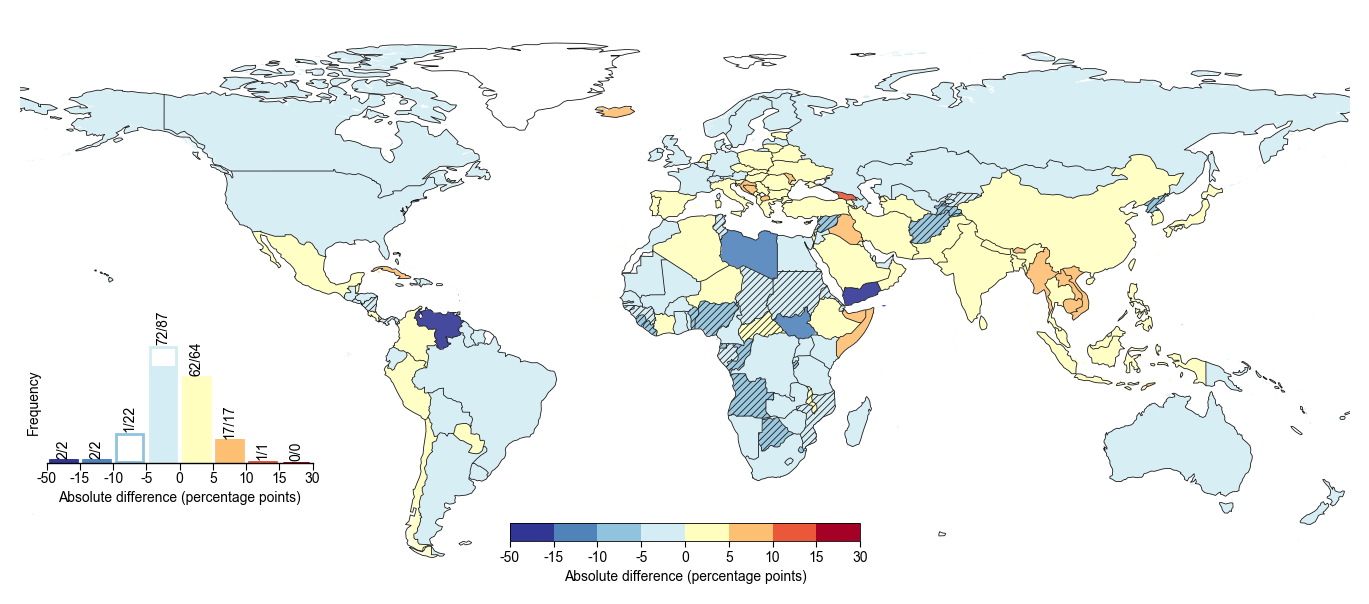

In [104]:
style = {
    "lines.linewidth": 0.5,
    "lines.markeredgewidth": 0.3,
    "font.size": 5.0,
    "font.family": "Arial",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.5,
    "axes.grid": False,
    "axes.labelsize": 5,
    "axes.labelpad": 2,
    "axes.labelweight": "normal",
    "axes.labelcolor": "black",
    "axes.xmargin": 0.01,
    "xtick.major.size": 2,
    "xtick.major.width": 0.4,
    "xtick.major.pad": 1.5,
    "ytick.major.size": 2,
    "ytick.major.width": 0.4,
    "ytick.major.pad": 1.5,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "hatch.linewidth": 0.1,
}

cbar_shrink = 0.3
cbar_pad = -0.1

cm = 1 / 2.54  # centimeters in inches

with mpl.rc_context(style):
    fig = plt.figure(layout="constrained", figsize=(18 * cm, 7.5 * cm), dpi=200)
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

    label = "international"
    df = national_int_traffic_trend.query("country in @countries_int").copy()
    df["dpa"] = df["pct_slope"] - global_int_trend

    bins = np.array([-0.5, -0.15, -0.1, -0.05, 0, 0.05, 0.1, 0.15, 0.3])
    c1 = plt.cm.RdYlBu_r(np.linspace(0, 0.5, (bins < 0).sum(), endpoint=False))
    c2 = plt.cm.RdYlBu_r(np.linspace(0.5, 1, (bins > 0).sum()))
    cmap = ListedColormap(np.vstack([c1, c2]))
    norm = mcolors.BoundaryNorm(
        boundaries=bins, ncolors=len(bins) - 1, extend="neither"
    )

    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
    ax.set_axis_off()

    adm0_ = adm0.assign(
        var1=lambda x: x["alpha2"].map(df.set_index("country")["dpa"].to_dict())
    )
    ax.add_geometries(
        adm0_["geometry"].values,
        crs=ccrs.PlateCarree(),
        array=adm0_["var1"].values,
        cmap=cmap,
        norm=norm,
        alpha=0.9,
        rasterized=True,
    )

    codes = df.loc[df["trend"] == "no trend", "country"].values
    ax.add_geometries(
        adm0_.loc[adm0_["alpha2"].isin(codes), "geometry"].values,
        crs=ccrs.PlateCarree(),
        fc="none",
        ec=".1",
        lw=0.0,
        hatch="//////////",
        hatch_linewidth=0.3,
        alpha=1,
        rasterized=True,
    )

    ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.LAND, facecolor="#FFFFFF", alpha=0.7, rasterized=True)

    ax_ = ax.inset_axes([0.02, 0.2, 0.2, 0.22])
    ct1 = pd.cut(
        df.query("country in @countries_int and trend != 'no trend'")["dpa"],
        bins=bins,
        ordered=True,
        right=False,
    ).value_counts(sort=False)
    ct2 = pd.cut(
        df.query("country in @countries_int and trend == 'no trend'")["dpa"],
        bins=bins,
        ordered=True,
        right=False,
    ).value_counts(sort=False)

    bars1 = ax_.bar(np.arange(len(ct1)), ct1.values)
    bars2 = ax_.bar(np.arange(len(ct2)), ct2.values, bottom=ct1.values)

    for i, (bar_1, bar_2) in enumerate(zip(bars1, bars2)):
        bar_1.set_fc(cmap(i / len(ct1)))
        bar_1.set_ec(cmap(i / len(ct1)))
        bar_2.set_fc("none")
        bar_2.set_ec(cmap(i / len(ct2)))

    for i, (ct1_, ct2_) in enumerate(zip(ct1, ct2)):
        ax_.text(
            i,
            ct1_ + ct2_ + 1.5,
            f"{ct1_}/{ct1_ + ct2_}",
            fontsize=5,
            va="bottom",
            ha="center",
            rotation=90,
        )

    ax_.tick_params(axis="both", size=2.5, pad=0.5)
    ax_.set_xticks(
        np.arange(len(bins)) - 0.5,
        labels=[
            f"{x * 100:.0f}" if x * 100 % 1 == 0 else f"{x * 100:.1f}" for x in bins
        ],
        fontsize=5,
        rotation=0,
    )
    ax_.set_yticks([])
    ax_.set_xlabel(r"Absolute difference (percentage points)", fontsize=5)
    ax_.set_ylabel("Frequency", fontsize=5)
    ax_.spines[["top", "left", "right"]].set_visible(False)

    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(cmap=cmap),
        ax=ax,
        orientation="horizontal",
        shrink=0.25,
        pad=-0.08,
    )
    cbar.set_ticks(
        np.linspace(0, 1, len(bins)),
        labels=[
            f"{x * 100:.0f}" if x * 100 % 1 == 0 else f"{x * 100:.1f}" for x in bins
        ],
        fontsize=5,
    )
    cbar.set_label(f"Absolute difference" + r" (percentage points)", fontsize=5)
    cbar.ax.get_children()[6].set_lw(0.3)

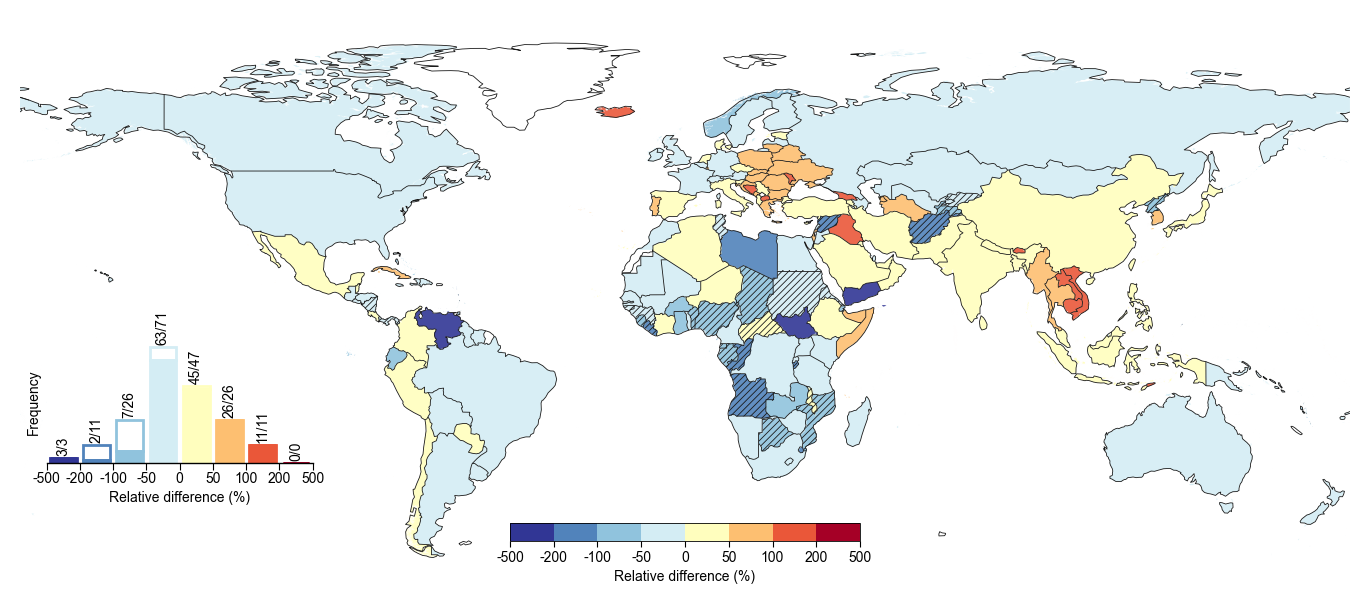

In [103]:
with mpl.rc_context(style):
    fig = plt.figure(layout="constrained", figsize=(18 * cm, 7.5 * cm), dpi=200)
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

    label = "international"
    df = national_int_traffic_trend.query("country in @countries_int").copy()
    df["dpa"] = (df["pct_slope"] - global_total_trend) / global_total_trend

    bins = np.array([-5, -2, -1, -0.5, 0, 0.5, 1, 2, 5])
    c1 = plt.cm.RdYlBu_r(np.linspace(0, 0.5, (bins < 0).sum(), endpoint=False))
    c2 = plt.cm.RdYlBu_r(np.linspace(0.5, 1, (bins > 0).sum()))
    cmap = ListedColormap(np.vstack([c1, c2]))
    norm = mcolors.BoundaryNorm(
        boundaries=bins, ncolors=len(bins) - 1, extend="neither"
    )

    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
    ax.set_axis_off()

    adm0_ = adm0.assign(
        var1=lambda x: x["alpha2"].map(df.set_index("country")["dpa"].to_dict())
    )
    ax.add_geometries(
        adm0_["geometry"].values,
        crs=ccrs.PlateCarree(),
        array=adm0_["var1"].values,
        cmap=cmap,
        norm=norm,
        alpha=0.9,
        rasterized=True,
    )

    codes = df.loc[df["trend"] == "no trend", "country"].values
    ax.add_geometries(
        adm0_.loc[adm0_["alpha2"].isin(codes), "geometry"].values,
        crs=ccrs.PlateCarree(),
        fc="none",
        ec=".1",
        lw=0.0,
        hatch="//////////",
        hatch_linewidth=0.3,
        alpha=1,
        rasterized=True,
    )

    ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.LAND, facecolor="#FFFFFF", alpha=0.7, rasterized=True)

    ax_ = ax.inset_axes([0.02, 0.2, 0.2, 0.22])
    ct1 = pd.cut(
        df.query("country in @countries_int and trend != 'no trend'")["dpa"],
        bins=bins,
        ordered=True,
        right=False,
    ).value_counts(sort=False)
    ct2 = pd.cut(
        df.query("country in @countries_int and trend == 'no trend'")["dpa"],
        bins=bins,
        ordered=True,
        right=False,
    ).value_counts(sort=False)

    bars1 = ax_.bar(np.arange(len(ct1)), ct1.values)
    bars2 = ax_.bar(np.arange(len(ct2)), ct2.values, bottom=ct1.values)

    for i, (bar_1, bar_2) in enumerate(zip(bars1, bars2)):
        bar_1.set_fc(cmap(i / len(ct1)))
        bar_1.set_ec(cmap(i / len(ct1)))
        bar_2.set_fc("none")
        bar_2.set_ec(cmap(i / len(ct2)))

    for i, (ct1_, ct2_) in enumerate(zip(ct1, ct2)):
        ax_.text(
            i,
            ct1_ + ct2_ + 1.5,
            f"{ct1_}/{ct1_ + ct2_}",
            fontsize=5,
            va="bottom",
            ha="center",
            rotation=90,
        )

    ax_.tick_params(axis="both", size=2.5, pad=0.5)
    ax_.set_xticks(
        np.arange(len(bins)) - 0.5,
        labels=[
            f"{x * 100:.0f}" if x * 100 % 1 == 0 else f"{x * 100:.1f}" for x in bins
        ],
        fontsize=5,
        rotation=0,
    )
    ax_.set_yticks([])
    ax_.set_xlabel(r"Relative difference (%)", fontsize=5)
    ax_.set_ylabel("Frequency", fontsize=5)
    ax_.spines[["top", "left", "right"]].set_visible(False)

    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(cmap=cmap),
        ax=ax,
        orientation="horizontal",
        shrink=0.25,
        pad=-0.08,
    )
    cbar.set_ticks(
        np.linspace(0, 1, len(bins)),
        labels=[
            f"{x * 100:.0f}" if x * 100 % 1 == 0 else f"{x * 100:.1f}" for x in bins
        ],
        fontsize=5,
    )
    cbar.set_label(f"Relative difference" + r" (%)", fontsize=5)
    cbar.ax.get_children()[6].set_lw(0.3)

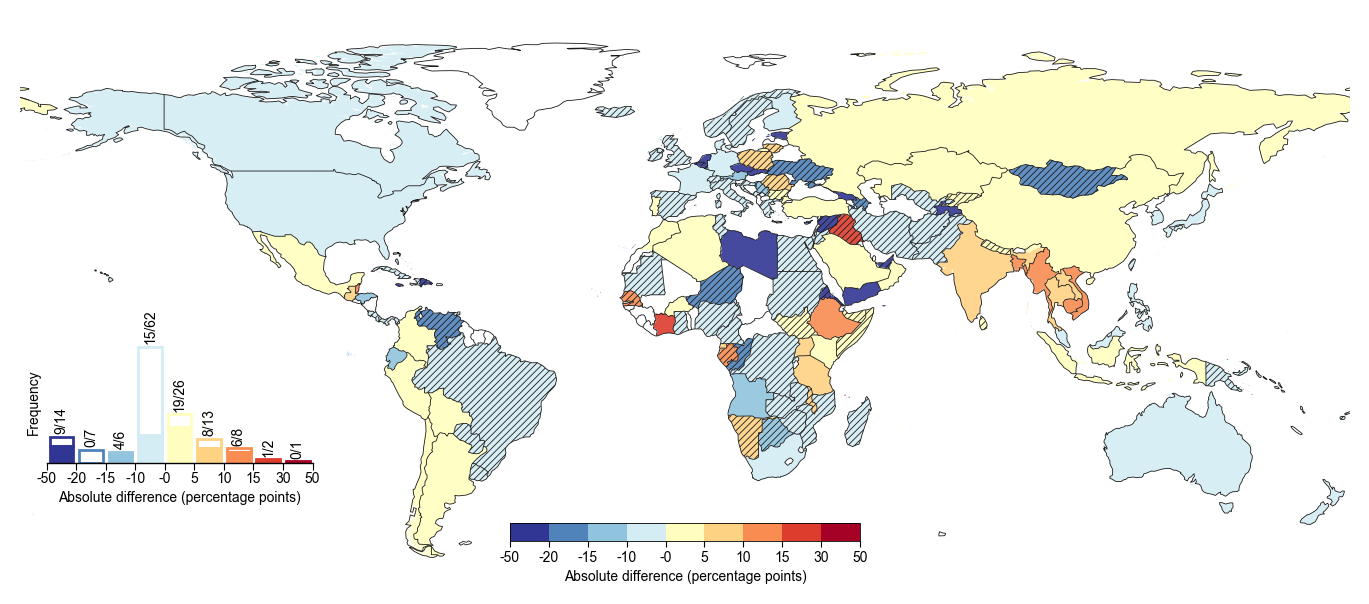

In [106]:
with mpl.rc_context(style):
    fig = plt.figure(layout="constrained", figsize=(18 * cm, 7.5 * cm), dpi=200)
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

    df = national_dom_traffic_trend.query("country in @countries_dom").copy()
    df["dpa"] = df["pct_slope"] - global_dom_trend

    bins = np.array([-0.5, -0.2, -0.15, -0.1, -0.0, 0.05, 0.1, 0.15, 0.3, 0.5])
    c1 = plt.cm.RdYlBu_r(np.linspace(0, 0.5, (bins < 0).sum(), endpoint=False))
    c2 = plt.cm.RdYlBu_r(np.linspace(0.5, 1, (bins > 0).sum()))
    cmap = ListedColormap(np.vstack([c1, c2]))
    norm = mcolors.BoundaryNorm(
        boundaries=bins, ncolors=len(bins) - 1, extend="neither"
    )

    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
    ax.set_axis_off()

    adm0_ = adm0.assign(
        var1=lambda x: x["alpha2"].map(df.set_index("country")["dpa"].to_dict())
    ).query("alpha2 in @countries_dom")
    ax.add_geometries(
        adm0_["geometry"].values,
        crs=ccrs.PlateCarree(),
        array=adm0_["var1"].values,
        cmap=cmap,
        norm=norm,
        alpha=0.9,
        rasterized=True,
    )

    codes = df.loc[df["trend"] == "no trend", "country"].values
    ax.add_geometries(
        adm0_.loc[adm0_["alpha2"].isin(codes), "geometry"].values,
        crs=ccrs.PlateCarree(),
        fc="none",
        ec=".1",
        lw=0.0,
        hatch="//////////",
        hatch_linewidth=0.3,
        alpha=1,
        rasterized=True,
    )

    ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.LAND, facecolor="#FFFFFF", alpha=0.7, rasterized=True)

    ax_ = ax.inset_axes([0.02, 0.2, 0.2, 0.22])
    ct1 = pd.cut(
        df.query("country in @countries_dom and trend != 'no trend'")["dpa"],
        bins=bins,
        ordered=True,
        right=False,
    ).value_counts(sort=False)
    ct2 = pd.cut(
        df.query("country in @countries_dom and trend == 'no trend'")["dpa"],
        bins=bins,
        ordered=True,
        right=False,
    ).value_counts(sort=False)

    bars1 = ax_.bar(np.arange(len(ct1)), ct1.values)
    bars2 = ax_.bar(np.arange(len(ct2)), ct2.values, bottom=ct1.values)

    for i, (bar_1, bar_2) in enumerate(zip(bars1, bars2)):
        bar_1.set_fc(cmap(i / len(ct1)))
        bar_1.set_ec(cmap(i / len(ct1)))
        bar_2.set_fc("none")
        bar_2.set_ec(cmap(i / len(ct2)))

    for i, (ct1_, ct2_) in enumerate(zip(ct1, ct2)):
        ax_.text(
            i,
            ct1_ + ct2_ + 1.5,
            f"{ct1_}/{ct1_ + ct2_}",
            fontsize=5,
            va="bottom",
            ha="center",
            rotation=90,
        )

    ax_.tick_params(axis="both", size=2.5, pad=0.5)
    ax_.set_xticks(
        np.arange(len(bins)) - 0.5,
        labels=[
            f"{x * 100:.0f}" if x * 100 % 1 == 0 else f"{x * 100:.1f}" for x in bins
        ],
        fontsize=5,
        rotation=0,
    )
    ax_.set_yticks([])
    ax_.set_xlabel(r"Absolute difference (percentage points)", fontsize=5)
    ax_.set_ylabel("Frequency", fontsize=5)
    ax_.spines[["top", "left", "right"]].set_visible(False)

    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(cmap=cmap),
        ax=ax,
        orientation="horizontal",
        shrink=0.25,
        pad=-0.08,
    )
    cbar.set_ticks(
        np.linspace(0, 1, len(bins)),
        labels=[
            f"{x * 100:.0f}" if x * 100 % 1 == 0 else f"{x * 100:.1f}" for x in bins
        ],
        fontsize=5,
    )
    # cbar.set_ticks(np.linspace(0,1,len(bins)), labels=['-30', '-20', '-15', '-10', '-5', '0', '2.5', '5', '7.5', '10', '15', '30', '40'])
    cbar.set_label(f"Absolute difference" + r" (percentage points)", fontsize=5)
    cbar.ax.get_children()[6].set_lw(0.3)

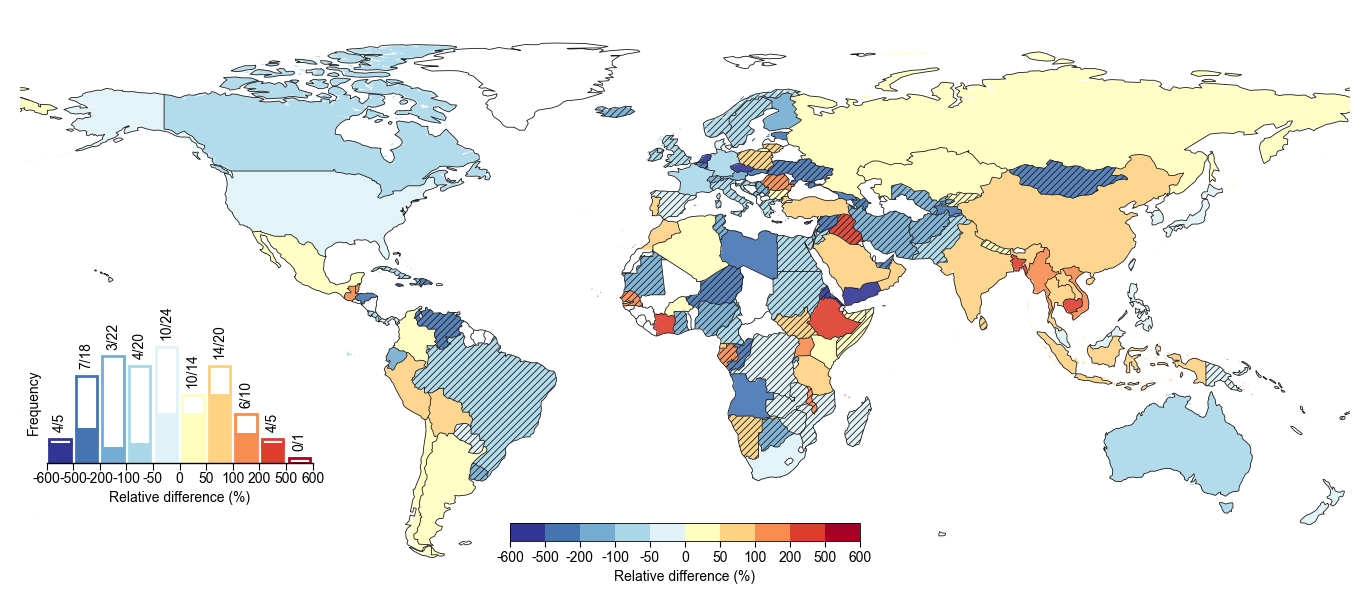

In [107]:
with mpl.rc_context(style):
    fig = plt.figure(layout="constrained", figsize=(18 * cm, 7.5 * cm), dpi=200)
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

    df = national_dom_traffic_trend.query("country in @countries_dom").copy()
    df["dpa"] = (df["pct_slope"] - global_dom_trend) / global_dom_trend

    bins = np.array([-6, -5, -2, -1, -0.5, 0, 0.5, 1, 2, 5, 6])
    c1 = plt.cm.RdYlBu_r(np.linspace(0, 0.5, (bins < 0).sum(), endpoint=False))
    c2 = plt.cm.RdYlBu_r(np.linspace(0.5, 1, (bins > 0).sum()))
    cmap = ListedColormap(np.vstack([c1, c2]))
    norm = mcolors.BoundaryNorm(
        boundaries=bins, ncolors=len(bins) - 1, extend="neither"
    )

    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
    ax.set_axis_off()

    adm0_ = adm0.assign(
        var1=lambda x: x["alpha2"].map(df.set_index("country")["dpa"].to_dict())
    ).query("alpha2 in @countries_dom")
    ax.add_geometries(
        adm0_["geometry"].values,
        crs=ccrs.PlateCarree(),
        array=adm0_["var1"].values,
        cmap=cmap,
        norm=norm,
        alpha=0.9,
        rasterized=True,
    )

    codes = df.loc[df["trend"] == "no trend", "country"].values
    ax.add_geometries(
        adm0_.loc[adm0_["alpha2"].isin(codes), "geometry"].values,
        crs=ccrs.PlateCarree(),
        fc="none",
        ec=".1",
        lw=0.0,
        hatch="//////////",
        hatch_linewidth=0.3,
        alpha=1,
        rasterized=True,
    )

    ax.add_feature(cfeature.COASTLINE, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.BORDERS, ls="-", edgecolor=".1", lw=0.3)
    ax.add_feature(cfeature.LAND, facecolor="#FFFFFF", alpha=0.7, rasterized=True)

    ax_ = ax.inset_axes([0.02, 0.2, 0.2, 0.22])
    ct1 = pd.cut(
        df.query("country in @countries_dom and trend != 'no trend'")["dpa"],
        bins=bins,
        ordered=True,
        right=False,
    ).value_counts(sort=False)
    ct2 = pd.cut(
        df.query("country in @countries_dom and trend == 'no trend'")["dpa"],
        bins=bins,
        ordered=True,
        right=False,
    ).value_counts(sort=False)

    bars1 = ax_.bar(np.arange(len(ct1)), ct1.values)
    bars2 = ax_.bar(np.arange(len(ct2)), ct2.values, bottom=ct1.values)

    for i, (bar_1, bar_2) in enumerate(zip(bars1, bars2)):
        bar_1.set_fc(cmap(i / len(ct1)))
        bar_1.set_ec(cmap(i / len(ct1)))
        bar_2.set_fc("none")
        bar_2.set_ec(cmap(i / len(ct2)))

    for i, (ct1_, ct2_) in enumerate(zip(ct1, ct2)):
        ax_.text(
            i,
            ct1_ + ct2_ + 1.5,
            f"{ct1_}/{ct1_ + ct2_}",
            fontsize=5,
            va="bottom",
            ha="center",
            rotation=90,
        )

    ax_.tick_params(axis="both", size=2.5, pad=0.5)
    ax_.set_xticks(
        np.arange(len(bins)) - 0.5,
        labels=[
            f"{x * 100:.0f}" if x * 100 % 1 == 0 else f"{x * 100:.1f}" for x in bins
        ],
        fontsize=5,
        rotation=0,
    )
    ax_.set_yticks([])
    ax_.set_xlabel(r"Relative difference (%)", fontsize=5)
    ax_.set_ylabel("Frequency", fontsize=5)
    ax_.spines[["top", "left", "right"]].set_visible(False)

    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(cmap=cmap),
        ax=ax,
        orientation="horizontal",
        shrink=0.25,
        pad=-0.08,
    )
    cbar.set_ticks(
        np.linspace(0, 1, len(bins)),
        labels=[
            f"{x * 100:.0f}" if x * 100 % 1 == 0 else f"{x * 100:.1f}" for x in bins
        ],
        fontsize=5,
    )
    # cbar.set_ticks(np.linspace(0,1,len(bins)), labels=['-30', '-20', '-15', '-10', '-5', '0', '2.5', '5', '7.5', '10', '15', '30', '40'])
    cbar.set_label(f"Relative difference" + r" (%)", fontsize=5)
    cbar.ax.get_children()[6].set_lw(0.3)